# IMPORT LIBRARIES

In [103]:
import json
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# IMPORT DATA

In [104]:
import json
import os
import re
import matplotlib.pyplot as plt

# -------------------------------------------------
# BASE FOLDERS
# -------------------------------------------------
results_dir = r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results"
instances_dir = r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\instances"

# -------------------------------------------------
# EXTRACT METRICS FROM JSON
# -------------------------------------------------
def get_metrics(vars_dict):
    z = vars_dict.get("z", {})
    y = vars_dict.get("y", {})
    hotel = vars_dict.get("hotel", {})
    L = vars_dict.get("L", {})
    idle = vars_dict.get("idle_away", {})

    return {
        "work_days": len(z),
        "travel_moves": len(y),
        "hotel_days": len(hotel),
        "idle_away_days": len(idle),
        "lateness": sum(float(v) for v in L.values()) if L else 0.0,
    }

# -------------------------------------------------
# FIND MATCHING FILE PAIRS BY SEED
# expected names:
#   economic_baseline_seed10.json
#   sustainability_aware_seed10.json
#   demo_clustered_seed10.json
# -------------------------------------------------
all_result_files = os.listdir(results_dir)
all_instance_files = os.listdir(instances_dir)

economic_files = {}
sustain_files = {}
instance_files = {}

for fname in all_result_files:
    econ_match = re.match(r"economic_baseline_seed(\d+)\.json$", fname)
    sust_match = re.match(r"sustainability_aware_seed(\d+)\.json$", fname)

    if econ_match:
        seed = econ_match.group(1)
        economic_files[seed] = fname

    if sust_match:
        seed = sust_match.group(1)
        sustain_files[seed] = fname

for fname in all_instance_files:
    inst_match = re.match(r"demo_clustered_seed(\d+)\.json$", fname)
    if inst_match:
        seed = inst_match.group(1)
        instance_files[seed] = fname

# seeds that exist in all three folders/groups
common_seeds = sorted(
    set(economic_files.keys()) & set(sustain_files.keys()) & set(instance_files.keys()),
    key=int
)

if not common_seeds:
    raise FileNotFoundError(
        "No matching triplets found:\n"
        "  economic_baseline_seedX.json\n"
        "  sustainability_aware_seedX.json\n"
        "  demo_clustered_seedX.json"
    )

print("Matched triplets:")
for seed in common_seeds:
    print(
        f"Seed {seed}: "
        f"{economic_files[seed]}  <->  "
        f"{sustain_files[seed]}  <->  "
        f"{instance_files[seed]}"
    )

Matched triplets:
Seed 10: economic_baseline_seed10.json  <->  sustainability_aware_seed10.json  <->  demo_clustered_seed10.json
Seed 11: economic_baseline_seed11.json  <->  sustainability_aware_seed11.json  <->  demo_clustered_seed11.json
Seed 12: economic_baseline_seed12.json  <->  sustainability_aware_seed12.json  <->  demo_clustered_seed12.json
Seed 18: economic_baseline_seed18.json  <->  sustainability_aware_seed18.json  <->  demo_clustered_seed18.json
Seed 19: economic_baseline_seed19.json  <->  sustainability_aware_seed19.json  <->  demo_clustered_seed19.json
Seed 20: economic_baseline_seed20.json  <->  sustainability_aware_seed20.json  <->  demo_clustered_seed20.json
Seed 21: economic_baseline_seed21.json  <->  sustainability_aware_seed21.json  <->  demo_clustered_seed21.json
Seed 22: economic_baseline_seed22.json  <->  sustainability_aware_seed22.json  <->  demo_clustered_seed22.json
Seed 23: economic_baseline_seed23.json  <->  sustainability_aware_seed23.json  <->  demo_clust

# ANALYZE

## OBJECTIVE FUNCTIONS

Matched triplets:
Seed 10: economic_baseline_seed10.json <-> sustainability_aware_seed10.json <-> demo_clustered_seed10.json
Seed 11: economic_baseline_seed11.json <-> sustainability_aware_seed11.json <-> demo_clustered_seed11.json
Seed 12: economic_baseline_seed12.json <-> sustainability_aware_seed12.json <-> demo_clustered_seed12.json
Seed 18: economic_baseline_seed18.json <-> sustainability_aware_seed18.json <-> demo_clustered_seed18.json
Seed 19: economic_baseline_seed19.json <-> sustainability_aware_seed19.json <-> demo_clustered_seed19.json
Seed 20: economic_baseline_seed20.json <-> sustainability_aware_seed20.json <-> demo_clustered_seed20.json
Seed 21: economic_baseline_seed21.json <-> sustainability_aware_seed21.json <-> demo_clustered_seed21.json
Seed 22: economic_baseline_seed22.json <-> sustainability_aware_seed22.json <-> demo_clustered_seed22.json
Seed 23: economic_baseline_seed23.json <-> sustainability_aware_seed23.json <-> demo_clustered_seed23.json
Seed 33: economic_b

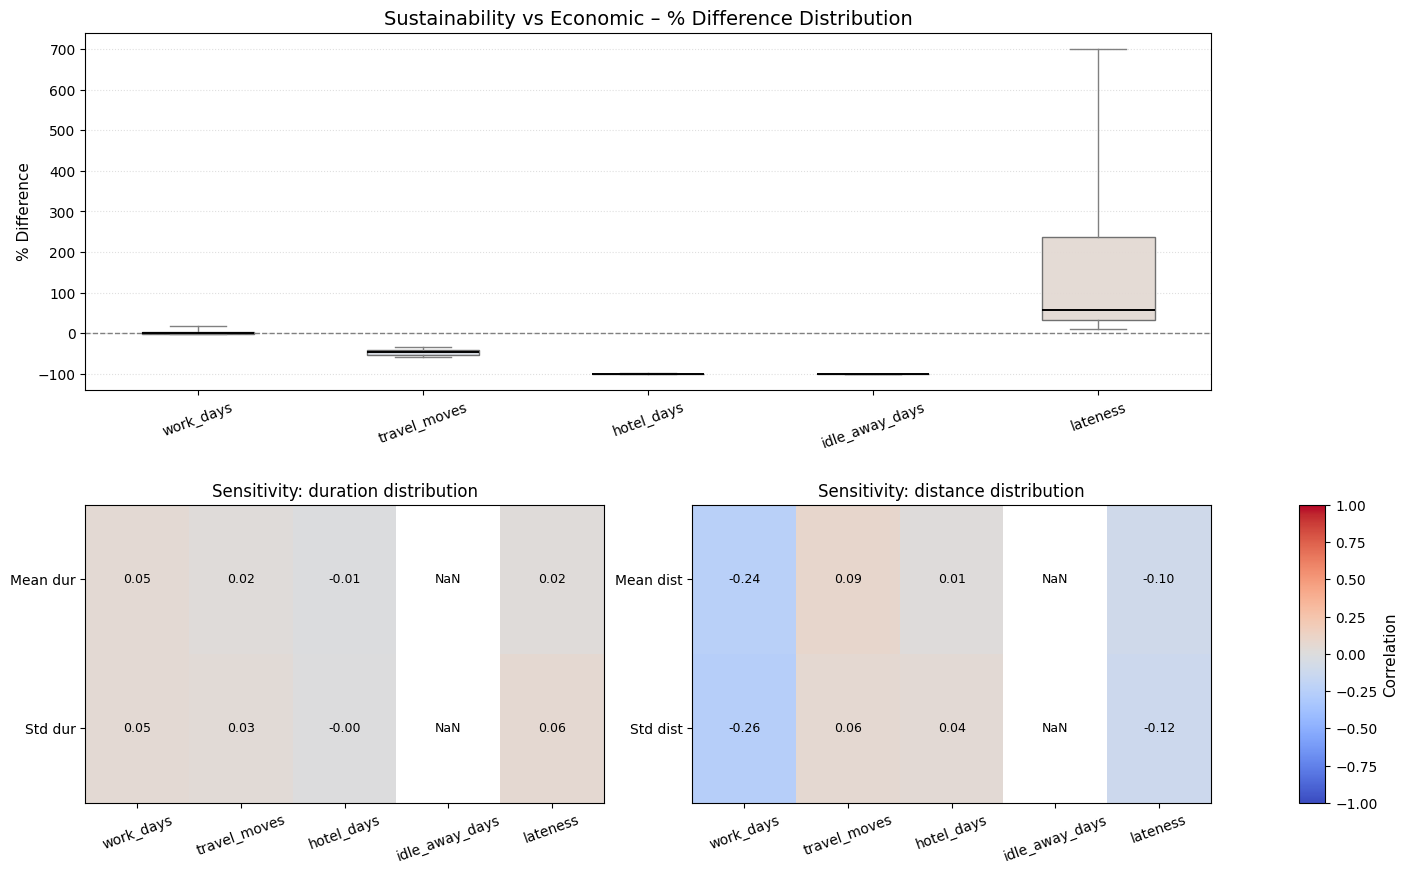

In [105]:
import json
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors, cm


# =================================================
# PATHS
# =================================================
RESULTS_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results")
INSTANCES_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\instances")


# =================================================
# BASIC UTILITIES
# =================================================
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def split_key(key, expected_len=None):
    parts = str(key).split("|")
    if expected_len is not None and len(parts) != expected_len:
        return None
    return parts


def safe_variables(data):
    return data.get("variables", {})


def safe_corr(x, y):
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)

    valid = x.notna() & y.notna()
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan

    return x.corr(y)


# =================================================
# FILE MATCHING
# =================================================
def collect_seed_files(results_dir, instances_dir):
    economic_files = {}
    sustainability_files = {}
    instance_files = {}

    for path in results_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"economic_baseline_seed(\d+)\.json", path.name)
        if m:
            economic_files[m.group(1)] = path
            continue

        m = re.fullmatch(r"sustainability_aware_seed(\d+)\.json", path.name)
        if m:
            sustainability_files[m.group(1)] = path

    for path in instances_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"demo_clustered_seed(\d+)\.json", path.name)
        if m:
            instance_files[m.group(1)] = path

    common_seeds = sorted(
        set(economic_files) & set(sustainability_files) & set(instance_files),
        key=int
    )

    if not common_seeds:
        raise FileNotFoundError(
            "No matching triplets found:\n"
            "  economic_baseline_seedX.json\n"
            "  sustainability_aware_seedX.json\n"
            "  demo_clustered_seedX.json"
        )

    print("Matched triplets:")
    for seed in common_seeds:
        print(
            f"Seed {seed}: "
            f"{economic_files[seed].name} <-> "
            f"{sustainability_files[seed].name} <-> "
            f"{instance_files[seed].name}"
        )

    return common_seeds, economic_files, sustainability_files, instance_files


# =================================================
# SOLUTION METRICS
# =================================================
def extract_solution_metrics(vars_dict):
    z = vars_dict.get("z", {})
    y = vars_dict.get("y", {})
    hotel = vars_dict.get("hotel", {})
    idle_away = vars_dict.get("idle_away", {})
    lateness = vars_dict.get("L", {})

    return {
        "work_days": len(z),
        "travel_moves": len(y),
        "hotel_days": len(hotel),
        "idle_away_days": len(idle_away),
        "lateness": sum(float(v) for v in lateness.values()) if lateness else 0.0,
    }


def compute_percentage_change(econ_value, sust_value):
    econ_value = float(econ_value)
    sust_value = float(sust_value)

    if abs(econ_value) < 1e-12:
        return np.nan

    return 100.0 * (sust_value - econ_value) / econ_value


# =================================================
# TECHNICIAN FEATURES
# =================================================
def technician_duration_lists(start_dict, dur_map):
    tech_to_durations = {}

    for key, val in start_dict.items():
        if float(val) <= 0.5:
            continue

        parts = split_key(key, expected_len=3)   # t | k | d
        if parts is None:
            continue

        task, tech, _day = parts
        dur_key = f"{task}|{tech}"
        duration = dur_map.get(dur_key)

        if duration is None or duration == 999:
            continue

        tech_to_durations.setdefault(tech, []).append(float(duration))

    return tech_to_durations


def technician_distance_lists(move_dict, dist_map):
    tech_to_distances = {}

    for key, val in move_dict.items():
        if float(val) <= 0.5:
            continue

        parts = split_key(key, expected_len=5)   # i | j | k | d | m
        if parts is None:
            continue

        origin, destination, tech, _day, _mode = parts
        dist_key = f"{origin}|{destination}"
        distance = dist_map.get(dist_key)

        if distance is None:
            continue

        tech_to_distances.setdefault(tech, []).append(float(distance))

    return tech_to_distances


def summarize_list(values):
    if not values:
        return np.nan, np.nan
    if len(values) == 1:
        return float(np.mean(values)), np.nan
    return float(np.mean(values)), float(np.std(values, ddof=1))


def build_technician_features(instance_data, econ_vars, sust_vars):
    dur_map = instance_data.get("dur", {})
    dist_map = instance_data.get("dist", {})
    tech_base = instance_data.get("base", {})
    technicians = sorted(tech_base.keys())

    econ_start = econ_vars.get("start", {})
    sust_start = sust_vars.get("start", {})
    econ_moves = econ_vars.get("y", {})
    sust_moves = sust_vars.get("y", {})

    econ_task_durations = technician_duration_lists(econ_start, dur_map)
    sust_task_durations = technician_duration_lists(sust_start, dur_map)

    econ_move_distances = technician_distance_lists(econ_moves, dist_map)
    sust_move_distances = technician_distance_lists(sust_moves, dist_map)

    rows = []
    for tech in technicians:
        econ_mean_dur, econ_std_dur = summarize_list(econ_task_durations.get(tech, []))
        sust_mean_dur, sust_std_dur = summarize_list(sust_task_durations.get(tech, []))

        econ_mean_dist, econ_std_dist = summarize_list(econ_move_distances.get(tech, []))
        sust_mean_dist, sust_std_dist = summarize_list(sust_move_distances.get(tech, []))

        rows.append({
            "tech": tech,
            "econ_mean_dur": econ_mean_dur,
            "econ_std_dur": econ_std_dur,
            "sust_mean_dur": sust_mean_dur,
            "sust_std_dur": sust_std_dur,
            "econ_mean_dist": econ_mean_dist,
            "econ_std_dist": econ_std_dist,
            "sust_mean_dist": sust_mean_dist,
            "sust_std_dist": sust_std_dist,
        })

    return pd.DataFrame(rows)


# =================================================
# BUILD TABLES
# =================================================
def build_analysis_tables(common_seeds, economic_files, sustainability_files, instance_files):
    seed_rows = []
    tech_frames = []

    metrics = ["work_days", "travel_moves", "hotel_days", "idle_away_days", "lateness"]

    for seed in common_seeds:
        econ_data = load_json(economic_files[seed])
        sust_data = load_json(sustainability_files[seed])
        inst_data = load_json(instance_files[seed])

        econ_vars = safe_variables(econ_data)
        sust_vars = safe_variables(sust_data)

        econ_metrics = extract_solution_metrics(econ_vars)
        sust_metrics = extract_solution_metrics(sust_vars)

        seed_row = {"seed": int(seed)}
        for metric in metrics:
            econ_value = econ_metrics[metric]
            sust_value = sust_metrics[metric]

            seed_row[f"econ_{metric}"] = econ_value
            seed_row[f"sust_{metric}"] = sust_value
            seed_row[f"diff_pct_{metric}"] = compute_percentage_change(econ_value, sust_value)

        seed_rows.append(seed_row)

        tech_df = build_technician_features(inst_data, econ_vars, sust_vars)
        tech_df["seed"] = int(seed)

        for metric in metrics:
            tech_df[f"diff_pct_{metric}"] = seed_row[f"diff_pct_{metric}"]

        tech_frames.append(tech_df)

    seed_df = pd.DataFrame(seed_rows).sort_values("seed").reset_index(drop=True)
    tech_df = pd.concat(tech_frames, ignore_index=True)

    diff_pct = seed_df[[f"diff_pct_{m}" for m in metrics]].copy()
    diff_pct.columns = metrics

    return metrics, seed_df, tech_df, diff_pct


# =================================================
# CORRELATION MATRICES
# =================================================
def build_correlation_matrices(metrics, tech_df):
    tech_df = tech_df.copy()

    tech_df["delta_mean_dur"] = tech_df["sust_mean_dur"] - tech_df["econ_mean_dur"]
    tech_df["delta_std_dur"] = tech_df["sust_std_dur"] - tech_df["econ_std_dur"]
    tech_df["delta_mean_dist"] = tech_df["sust_mean_dist"] - tech_df["econ_mean_dist"]
    tech_df["delta_std_dist"] = tech_df["sust_std_dist"] - tech_df["econ_std_dist"]

    dur_corr = pd.DataFrame(index=["Mean dur", "Std dur"], columns=metrics, dtype=float)
    dist_corr = pd.DataFrame(index=["Mean dist", "Std dist"], columns=metrics, dtype=float)

    for metric in metrics:
        x = tech_df[f"diff_pct_{metric}"]

        dur_corr.loc["Mean dur", metric] = safe_corr(x, tech_df["delta_mean_dur"])
        dur_corr.loc["Std dur", metric] = safe_corr(x, tech_df["delta_std_dur"])

        dist_corr.loc["Mean dist", metric] = safe_corr(x, tech_df["delta_mean_dist"])
        dist_corr.loc["Std dist", metric] = safe_corr(x, tech_df["delta_std_dist"])

    return dur_corr, dist_corr


# =================================================
# PLOT HELPERS
# =================================================
def annotate_heatmap(ax, df):
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            value = df.iloc[i, j]
            text = "NaN" if pd.isna(value) else f"{value:.2f}"
            ax.text(j, i, text, ha="center", va="center", fontsize=9)


# =================================================
# PLOT
# =================================================
def plot_results(metrics, diff_pct, dur_corr, dist_corr):
    # Shared diverging colormap for boxplot + heatmaps
    cmap = plt.get_cmap("coolwarm")

    # Correlation scale for heatmaps
    heat_norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    # Symmetric scale around zero for boxplot coloring
    box_data = [diff_pct[m].dropna().values.astype(float) for m in metrics]
    valid_box_data = [arr for arr in box_data if len(arr) > 0]

    if not valid_box_data:
        raise ValueError("No valid boxplot data available.")

    box_abs_max = max(np.nanmax(np.abs(arr)) for arr in valid_box_data)
    box_abs_max = max(box_abs_max, 1e-9)
    box_norm = colors.TwoSlopeNorm(vmin=-box_abs_max, vcenter=0, vmax=box_abs_max)

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(
        2, 3,
        height_ratios=[1.2, 1.0],
        width_ratios=[1, 1, 0.05],
        hspace=0.35,
        wspace=0.25
    )

    # ---------------- TOP: BOXPLOT ----------------
    ax_top = fig.add_subplot(gs[0, :2])

    bp = ax_top.boxplot(
        box_data,
        labels=metrics,
        patch_artist=True,
        showfliers=False,   # removes outlier points from plot
        whis=(5, 95)        # cleaner whiskers based on percentiles
    )

    # Color each box according to its median value using same colormap
    for patch, arr in zip(bp["boxes"], box_data):
        median_val = np.nanmedian(arr) if len(arr) > 0 else 0.0
        patch.set_facecolor(cmap(box_norm(median_val)))
        patch.set_edgecolor("dimgray")
        patch.set_linewidth(1.0)
        patch.set_alpha(0.95)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.4)

    for whisker in bp["whiskers"]:
        whisker.set_color("gray")
        whisker.set_linewidth(1.0)

    for cap in bp["caps"]:
        cap.set_color("gray")
        cap.set_linewidth(1.0)

    ax_top.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax_top.set_title("Sustainability vs Economic – % Difference Distribution", fontsize=14)
    ax_top.set_ylabel("% Difference", fontsize=11)
    ax_top.tick_params(axis="x", rotation=20)
    ax_top.grid(axis="y", linestyle=":", alpha=0.4)

    # ---------------- BOTTOM LEFT: DURATION ----------------
    ax_left = fig.add_subplot(gs[1, 0])
    im_left = ax_left.imshow(
        dur_corr.values.astype(float),
        cmap=cmap,
        norm=heat_norm,
        aspect="auto"
    )

    ax_left.set_xticks(np.arange(len(metrics)))
    ax_left.set_xticklabels(metrics, rotation=20)
    ax_left.set_yticks(np.arange(len(dur_corr.index)))
    ax_left.set_yticklabels(dur_corr.index)
    ax_left.set_title("Sensitivity: duration distribution", fontsize=12)

    annotate_heatmap(ax_left, dur_corr)

    # ---------------- BOTTOM RIGHT: DISTANCE ----------------
    ax_right = fig.add_subplot(gs[1, 1])
    im_right = ax_right.imshow(
        dist_corr.values.astype(float),
        cmap=cmap,
        norm=heat_norm,
        aspect="auto"
    )

    ax_right.set_xticks(np.arange(len(metrics)))
    ax_right.set_xticklabels(metrics, rotation=20)
    ax_right.set_yticks(np.arange(len(dist_corr.index)))
    ax_right.set_yticklabels(dist_corr.index)
    ax_right.set_title("Sensitivity: distance distribution", fontsize=12)

    annotate_heatmap(ax_right, dist_corr)

    # ---------------- COLORBAR ----------------
    cax = fig.add_subplot(gs[1, 2])
    sm = cm.ScalarMappable(norm=heat_norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Correlation", fontsize=11)

    plt.show()


# =================================================
# MAIN
# =================================================
common_seeds, economic_files, sustainability_files, instance_files = collect_seed_files(
    RESULTS_DIR,
    INSTANCES_DIR
)

metrics, seed_df, tech_df, diff_pct = build_analysis_tables(
    common_seeds,
    economic_files,
    sustainability_files,
    instance_files
)

dur_corr, dist_corr = build_correlation_matrices(metrics, tech_df)

print("\nSeed-level % differences:")
print(diff_pct.round(2))

print("\nDuration sensitivity correlation:")
print(dur_corr.round(3))

print("\nDistance sensitivity correlation:")
print(dist_corr.round(3))

plot_results(metrics, diff_pct, dur_corr, dist_corr)

Matched triplets:
Seed 10: economic_baseline_seed10.json <-> sustainability_aware_seed10.json <-> demo_clustered_seed10.json
Seed 11: economic_baseline_seed11.json <-> sustainability_aware_seed11.json <-> demo_clustered_seed11.json
Seed 12: economic_baseline_seed12.json <-> sustainability_aware_seed12.json <-> demo_clustered_seed12.json
Seed 18: economic_baseline_seed18.json <-> sustainability_aware_seed18.json <-> demo_clustered_seed18.json
Seed 19: economic_baseline_seed19.json <-> sustainability_aware_seed19.json <-> demo_clustered_seed19.json
Seed 20: economic_baseline_seed20.json <-> sustainability_aware_seed20.json <-> demo_clustered_seed20.json
Seed 21: economic_baseline_seed21.json <-> sustainability_aware_seed21.json <-> demo_clustered_seed21.json
Seed 22: economic_baseline_seed22.json <-> sustainability_aware_seed22.json <-> demo_clustered_seed22.json
Seed 23: economic_baseline_seed23.json <-> sustainability_aware_seed23.json <-> demo_clustered_seed23.json
Seed 33: economic_b

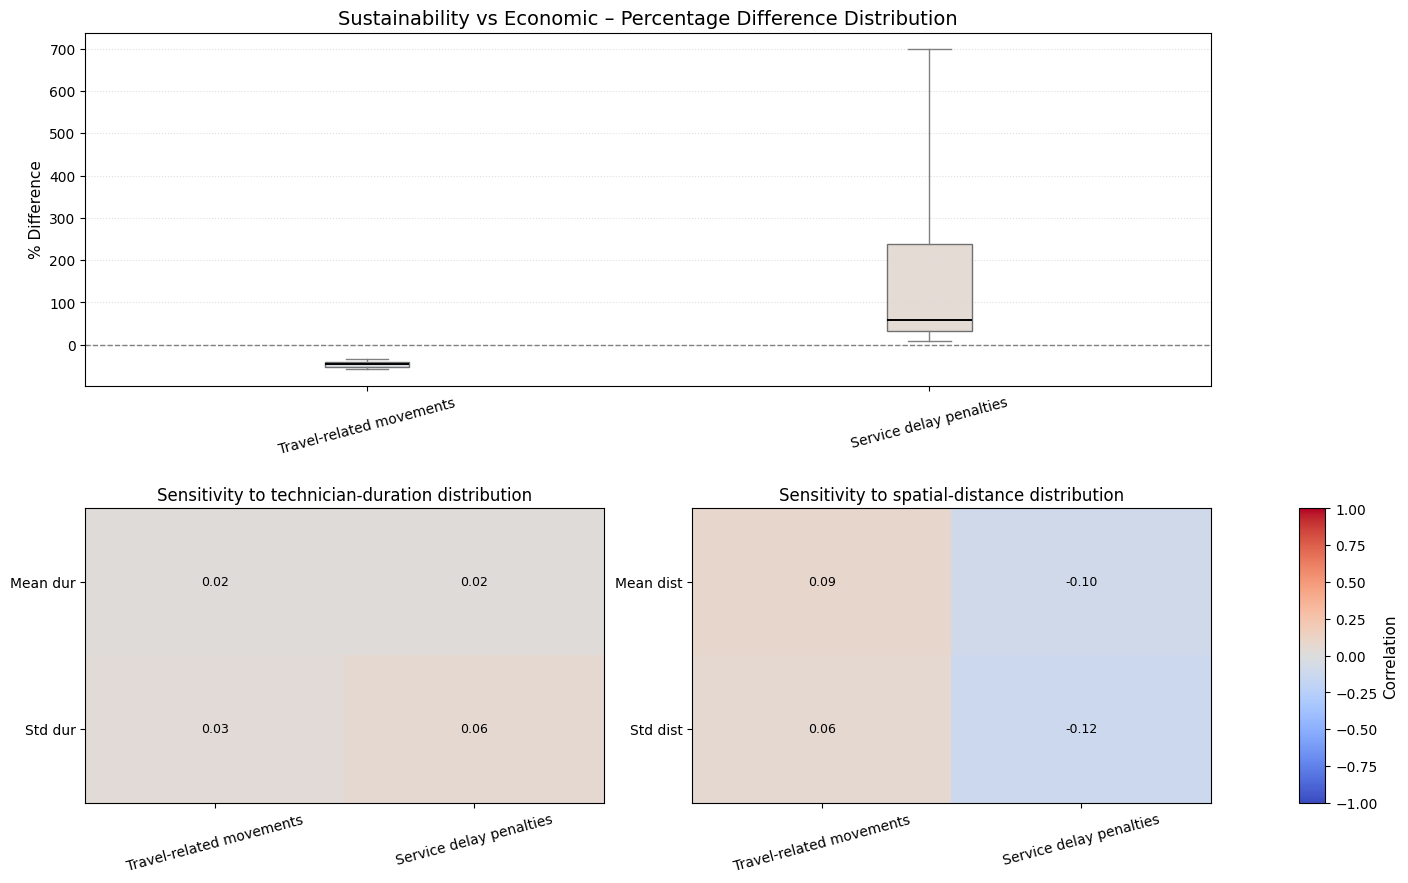

In [106]:
import json
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors, cm


# =================================================
# PATHS
# =================================================
RESULTS_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results")
INSTANCES_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\instances")


# =================================================
# BASIC UTILITIES
# =================================================
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def split_key(key, expected_len=None):
    parts = str(key).split("|")
    if expected_len is not None and len(parts) != expected_len:
        return None
    return parts


def safe_variables(data):
    return data.get("variables", {})


def safe_corr(x, y):
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)

    valid = x.notna() & y.notna()
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan

    return x.corr(y)


# =================================================
# FILE MATCHING
# =================================================
def collect_seed_files(results_dir, instances_dir):
    economic_files = {}
    sustainability_files = {}
    instance_files = {}

    for path in results_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"economic_baseline_seed(\d+)\.json", path.name)
        if m:
            economic_files[m.group(1)] = path
            continue

        m = re.fullmatch(r"sustainability_aware_seed(\d+)\.json", path.name)
        if m:
            sustainability_files[m.group(1)] = path

    for path in instances_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"demo_clustered_seed(\d+)\.json", path.name)
        if m:
            instance_files[m.group(1)] = path

    common_seeds = sorted(
        set(economic_files) & set(sustainability_files) & set(instance_files),
        key=int
    )

    if not common_seeds:
        raise FileNotFoundError(
            "No matching triplets found:\n"
            "  economic_baseline_seedX.json\n"
            "  sustainability_aware_seedX.json\n"
            "  demo_clustered_seedX.json"
        )

    print("Matched triplets:")
    for seed in common_seeds:
        print(
            f"Seed {seed}: "
            f"{economic_files[seed].name} <-> "
            f"{sustainability_files[seed].name} <-> "
            f"{instance_files[seed].name}"
        )

    return common_seeds, economic_files, sustainability_files, instance_files


# =================================================
# SOLUTION METRICS
# =================================================
def extract_solution_metrics(vars_dict):
    z = vars_dict.get("z", {})
    y = vars_dict.get("y", {})
    hotel = vars_dict.get("hotel", {})
    idle_away = vars_dict.get("idle_away", {})
    lateness = vars_dict.get("L", {})

    return {
        "work_days": len(z),
        "travel_moves": len(y),
        "hotel_days": len(hotel),
        "idle_away_days": len(idle_away),
        "lateness": sum(float(v) for v in lateness.values()) if lateness else 0.0,
    }


def compute_percentage_change(econ_value, sust_value):
    econ_value = float(econ_value)
    sust_value = float(sust_value)

    if abs(econ_value) < 1e-12:
        return np.nan

    return 100.0 * (sust_value - econ_value) / econ_value


# =================================================
# TECHNICIAN FEATURES
# =================================================
def technician_duration_lists(start_dict, dur_map):
    tech_to_durations = {}

    for key, val in start_dict.items():
        if float(val) <= 0.5:
            continue

        parts = split_key(key, expected_len=3)   # t | k | d
        if parts is None:
            continue

        task, tech, _day = parts
        dur_key = f"{task}|{tech}"
        duration = dur_map.get(dur_key)

        if duration is None or duration == 999:
            continue

        tech_to_durations.setdefault(tech, []).append(float(duration))

    return tech_to_durations


def technician_distance_lists(move_dict, dist_map):
    tech_to_distances = {}

    for key, val in move_dict.items():
        if float(val) <= 0.5:
            continue

        parts = split_key(key, expected_len=5)   # i | j | k | d | m
        if parts is None:
            continue

        origin, destination, tech, _day, _mode = parts
        dist_key = f"{origin}|{destination}"
        distance = dist_map.get(dist_key)

        if distance is None:
            continue

        tech_to_distances.setdefault(tech, []).append(float(distance))

    return tech_to_distances


def summarize_list(values):
    if not values:
        return np.nan, np.nan
    if len(values) == 1:
        return float(np.mean(values)), np.nan
    return float(np.mean(values)), float(np.std(values, ddof=1))


def build_technician_features(instance_data, econ_vars, sust_vars):
    dur_map = instance_data.get("dur", {})
    dist_map = instance_data.get("dist", {})
    tech_base = instance_data.get("base", {})
    technicians = sorted(tech_base.keys())

    econ_start = econ_vars.get("start", {})
    sust_start = sust_vars.get("start", {})
    econ_moves = econ_vars.get("y", {})
    sust_moves = sust_vars.get("y", {})

    econ_task_durations = technician_duration_lists(econ_start, dur_map)
    sust_task_durations = technician_duration_lists(sust_start, dur_map)

    econ_move_distances = technician_distance_lists(econ_moves, dist_map)
    sust_move_distances = technician_distance_lists(sust_moves, dist_map)

    rows = []
    for tech in technicians:
        econ_mean_dur, econ_std_dur = summarize_list(econ_task_durations.get(tech, []))
        sust_mean_dur, sust_std_dur = summarize_list(sust_task_durations.get(tech, []))

        econ_mean_dist, econ_std_dist = summarize_list(econ_move_distances.get(tech, []))
        sust_mean_dist, sust_std_dist = summarize_list(sust_move_distances.get(tech, []))

        rows.append({
            "tech": tech,
            "econ_mean_dur": econ_mean_dur,
            "econ_std_dur": econ_std_dur,
            "sust_mean_dur": sust_mean_dur,
            "sust_std_dur": sust_std_dur,
            "econ_mean_dist": econ_mean_dist,
            "econ_std_dist": econ_std_dist,
            "sust_mean_dist": sust_mean_dist,
            "sust_std_dist": sust_std_dist,
        })

    return pd.DataFrame(rows)


# =================================================
# BUILD TABLES
# =================================================
def build_analysis_tables(common_seeds, economic_files, sustainability_files, instance_files):
    seed_rows = []
    tech_frames = []

    all_metrics = ["work_days", "travel_moves", "hotel_days", "idle_away_days", "lateness"]

    # Keep only the metrics you want to visualize
    metrics_to_plot = ["travel_moves", "lateness"]

    for seed in common_seeds:
        econ_data = load_json(economic_files[seed])
        sust_data = load_json(sustainability_files[seed])
        inst_data = load_json(instance_files[seed])

        econ_vars = safe_variables(econ_data)
        sust_vars = safe_variables(sust_data)

        econ_metrics = extract_solution_metrics(econ_vars)
        sust_metrics = extract_solution_metrics(sust_vars)

        seed_row = {"seed": int(seed)}
        for metric in all_metrics:
            econ_value = econ_metrics[metric]
            sust_value = sust_metrics[metric]

            seed_row[f"econ_{metric}"] = econ_value
            seed_row[f"sust_{metric}"] = sust_value
            seed_row[f"diff_pct_{metric}"] = compute_percentage_change(econ_value, sust_value)

        seed_rows.append(seed_row)

        tech_df = build_technician_features(inst_data, econ_vars, sust_vars)
        tech_df["seed"] = int(seed)

        for metric in all_metrics:
            tech_df[f"diff_pct_{metric}"] = seed_row[f"diff_pct_{metric}"]

        tech_frames.append(tech_df)

    seed_df = pd.DataFrame(seed_rows).sort_values("seed").reset_index(drop=True)
    tech_df = pd.concat(tech_frames, ignore_index=True)

    diff_pct = seed_df[[f"diff_pct_{m}" for m in metrics_to_plot]].copy()
    diff_pct.columns = metrics_to_plot

    return metrics_to_plot, seed_df, tech_df, diff_pct


# =================================================
# CORRELATION MATRICES
# =================================================
def build_correlation_matrices(metrics, tech_df):
    tech_df = tech_df.copy()

    tech_df["delta_mean_dur"] = tech_df["sust_mean_dur"] - tech_df["econ_mean_dur"]
    tech_df["delta_std_dur"] = tech_df["sust_std_dur"] - tech_df["econ_std_dur"]
    tech_df["delta_mean_dist"] = tech_df["sust_mean_dist"] - tech_df["econ_mean_dist"]
    tech_df["delta_std_dist"] = tech_df["sust_std_dist"] - tech_df["econ_std_dist"]

    dur_corr = pd.DataFrame(index=["Mean dur", "Std dur"], columns=metrics, dtype=float)
    dist_corr = pd.DataFrame(index=["Mean dist", "Std dist"], columns=metrics, dtype=float)

    for metric in metrics:
        x = tech_df[f"diff_pct_{metric}"]

        dur_corr.loc["Mean dur", metric] = safe_corr(x, tech_df["delta_mean_dur"])
        dur_corr.loc["Std dur", metric] = safe_corr(x, tech_df["delta_std_dur"])

        dist_corr.loc["Mean dist", metric] = safe_corr(x, tech_df["delta_mean_dist"])
        dist_corr.loc["Std dist", metric] = safe_corr(x, tech_df["delta_std_dist"])

    return dur_corr, dist_corr


# =================================================
# PLOT HELPERS
# =================================================
def annotate_heatmap(ax, df):
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            value = df.iloc[i, j]
            text = "NaN" if pd.isna(value) else f"{value:.2f}"
            ax.text(j, i, text, ha="center", va="center", fontsize=9)


# =================================================
# PLOT
# =================================================
def plot_results(metrics, diff_pct, dur_corr, dist_corr):
    cmap = plt.get_cmap("coolwarm")
    heat_norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    box_data = [diff_pct[m].dropna().values.astype(float) for m in metrics]
    valid_box_data = [arr for arr in box_data if len(arr) > 0]

    if not valid_box_data:
        raise ValueError("No valid boxplot data available.")

    box_abs_max = max(np.nanmax(np.abs(arr)) for arr in valid_box_data)
    box_abs_max = max(box_abs_max, 1e-9)
    box_norm = colors.TwoSlopeNorm(vmin=-box_abs_max, vcenter=0, vmax=box_abs_max)

    # Cleaner display labels
    label_map = {
        "travel_moves": "Travel-related movements",
        "lateness": "Service delay penalties",
    }
    plot_labels = [label_map.get(m, m) for m in metrics]

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(
        2, 3,
        height_ratios=[1.2, 1.0],
        width_ratios=[1, 1, 0.05],
        hspace=0.38,
        wspace=0.25
    )

    # ---------------- TOP: BOXPLOT ----------------
    ax_top = fig.add_subplot(gs[0, :2])

    bp = ax_top.boxplot(
        box_data,
        labels=plot_labels,
        patch_artist=True,
        showfliers=False,
        whis=(5, 95)
    )

    for patch, arr in zip(bp["boxes"], box_data):
        median_val = np.nanmedian(arr) if len(arr) > 0 else 0.0
        patch.set_facecolor(cmap(box_norm(median_val)))
        patch.set_edgecolor("dimgray")
        patch.set_linewidth(1.0)
        patch.set_alpha(0.95)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.4)

    for whisker in bp["whiskers"]:
        whisker.set_color("gray")
        whisker.set_linewidth(1.0)

    for cap in bp["caps"]:
        cap.set_color("gray")
        cap.set_linewidth(1.0)

    ax_top.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax_top.set_title(
        "Sustainability vs Economic – Percentage Difference Distribution",
        fontsize=14
    )
    ax_top.set_ylabel("% Difference", fontsize=11)
    ax_top.tick_params(axis="x", rotation=15)
    ax_top.grid(axis="y", linestyle=":", alpha=0.4)

    # ---------------- BOTTOM LEFT: DURATION ----------------
    ax_left = fig.add_subplot(gs[1, 0])
    im_left = ax_left.imshow(
        dur_corr.values.astype(float),
        cmap=cmap,
        norm=heat_norm,
        aspect="auto"
    )

    ax_left.set_xticks(np.arange(len(metrics)))
    ax_left.set_xticklabels(plot_labels, rotation=15)
    ax_left.set_yticks(np.arange(len(dur_corr.index)))
    ax_left.set_yticklabels(dur_corr.index)
    ax_left.set_title("Sensitivity to technician-duration distribution", fontsize=12)

    annotate_heatmap(ax_left, dur_corr)

    # ---------------- BOTTOM RIGHT: DISTANCE ----------------
    ax_right = fig.add_subplot(gs[1, 1])
    im_right = ax_right.imshow(
        dist_corr.values.astype(float),
        cmap=cmap,
        norm=heat_norm,
        aspect="auto"
    )

    ax_right.set_xticks(np.arange(len(metrics)))
    ax_right.set_xticklabels(plot_labels, rotation=15)
    ax_right.set_yticks(np.arange(len(dist_corr.index)))
    ax_right.set_yticklabels(dist_corr.index)
    ax_right.set_title("Sensitivity to spatial-distance distribution", fontsize=12)

    annotate_heatmap(ax_right, dist_corr)

    # ---------------- COLORBAR ----------------
    cax = fig.add_subplot(gs[1, 2])
    sm = cm.ScalarMappable(norm=heat_norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Correlation", fontsize=11)

    plt.show()


# =================================================
# MAIN
# =================================================
common_seeds, economic_files, sustainability_files, instance_files = collect_seed_files(
    RESULTS_DIR,
    INSTANCES_DIR
)

metrics, seed_df, tech_df, diff_pct = build_analysis_tables(
    common_seeds,
    economic_files,
    sustainability_files,
    instance_files
)

dur_corr, dist_corr = build_correlation_matrices(metrics, tech_df)

print("\nSeed-level % differences:")
print(diff_pct.round(2))

print("\nDuration sensitivity correlation:")
print(dur_corr.round(3))

print("\nDistance sensitivity correlation:")
print(dist_corr.round(3))

plot_results(metrics, diff_pct, dur_corr, dist_corr)

Matched triplets:
Seed 10: economic_baseline_seed10.json <-> sustainability_aware_seed10.json <-> demo_clustered_seed10.json
Seed 11: economic_baseline_seed11.json <-> sustainability_aware_seed11.json <-> demo_clustered_seed11.json
Seed 12: economic_baseline_seed12.json <-> sustainability_aware_seed12.json <-> demo_clustered_seed12.json
Seed 18: economic_baseline_seed18.json <-> sustainability_aware_seed18.json <-> demo_clustered_seed18.json
Seed 19: economic_baseline_seed19.json <-> sustainability_aware_seed19.json <-> demo_clustered_seed19.json
Seed 20: economic_baseline_seed20.json <-> sustainability_aware_seed20.json <-> demo_clustered_seed20.json
Seed 21: economic_baseline_seed21.json <-> sustainability_aware_seed21.json <-> demo_clustered_seed21.json
Seed 22: economic_baseline_seed22.json <-> sustainability_aware_seed22.json <-> demo_clustered_seed22.json
Seed 23: economic_baseline_seed23.json <-> sustainability_aware_seed23.json <-> demo_clustered_seed23.json
Seed 33: economic_b

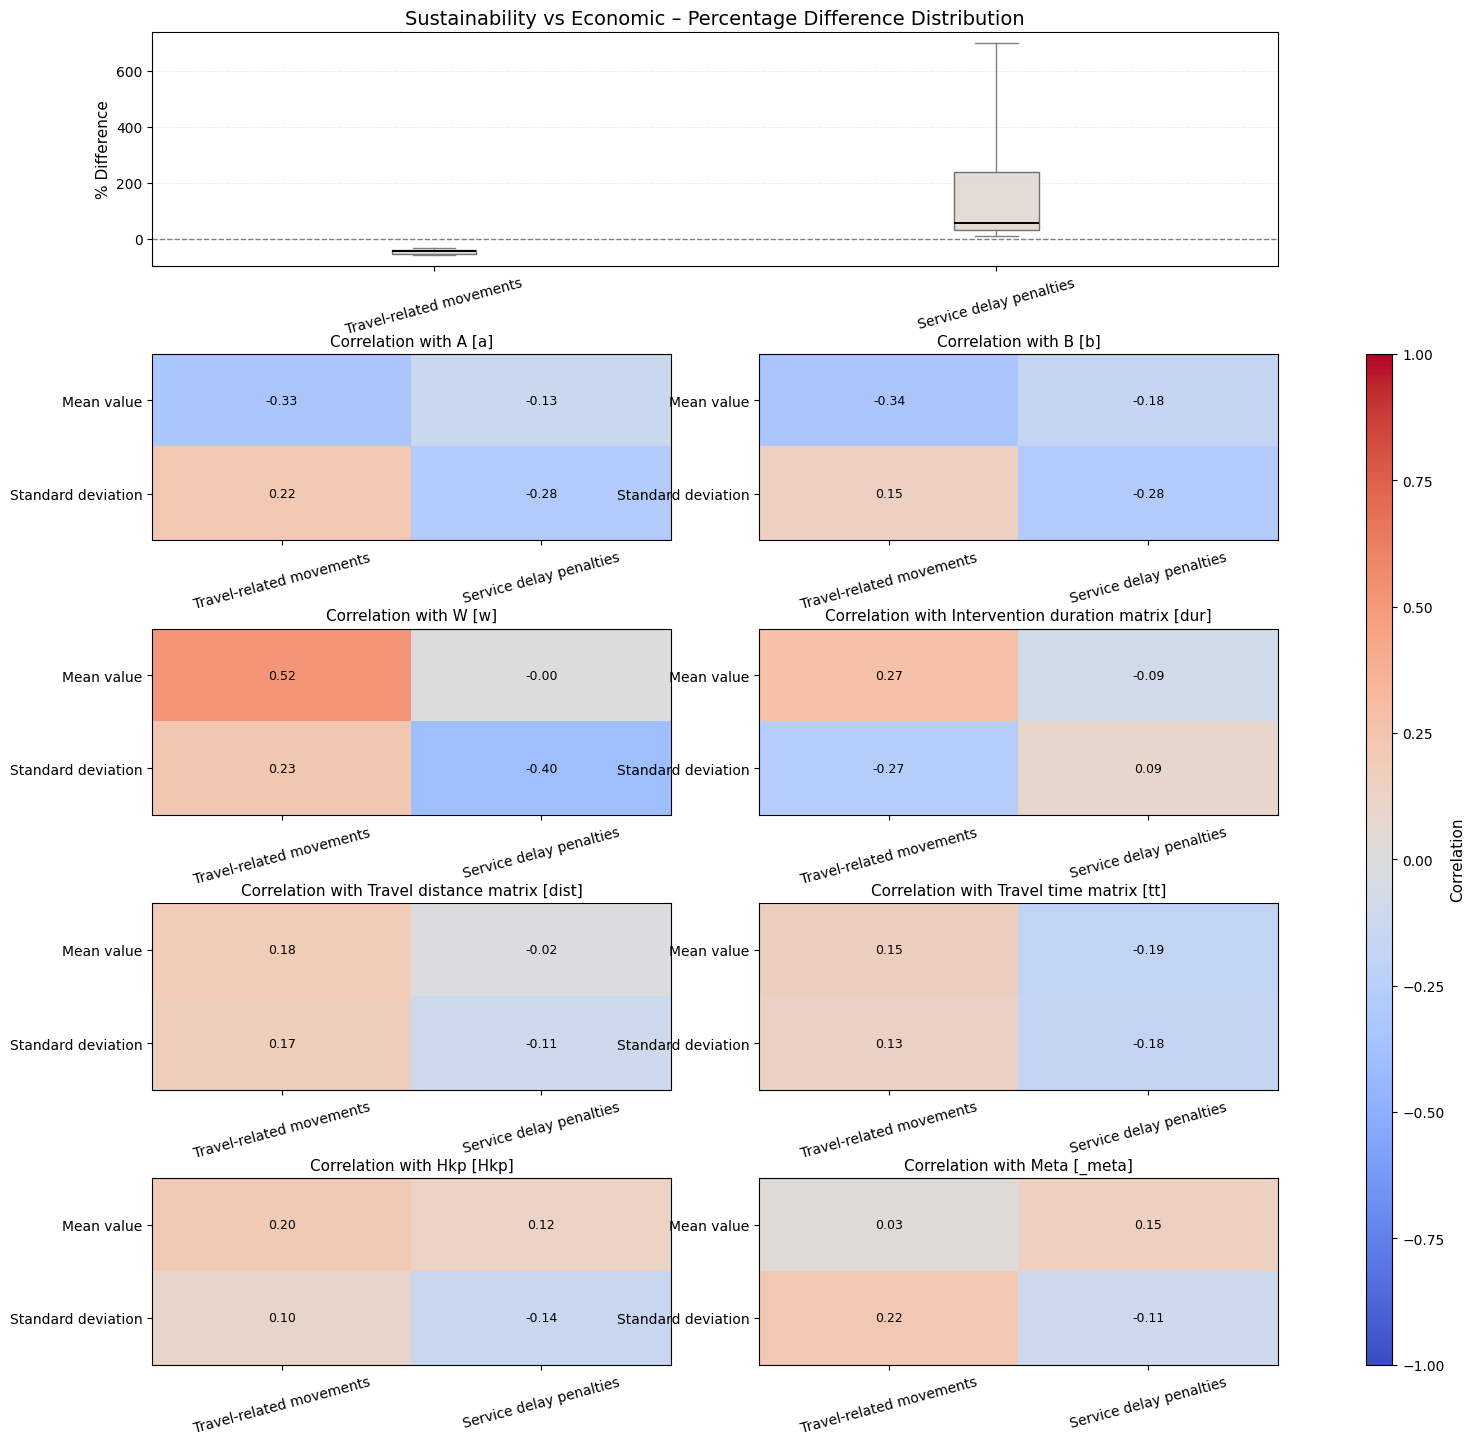

In [107]:
import json
import re
from math import ceil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors, cm


# =================================================
# PATHS
# =================================================
RESULTS_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results")
INSTANCES_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\instances")


# =================================================
# SETTINGS
# =================================================
METRICS_TO_PLOT = ["travel_moves", "lateness"]

METRIC_LABELS = {
    "travel_moves": "Travel-related movements",
    "lateness": "Service delay penalties",
}

INSTANCE_FEATURE_LABELS = {
    "dur": "Intervention duration matrix",
    "dist": "Travel distance matrix",
    "tt": "Travel time matrix",
    "emission": "Travel emission matrix",
    "co2": "Travel emission matrix",
    "cost": "Cost matrix",
    "travel_cost": "Travel cost matrix",
    "hotel_cost": "Hotel cost vector",
    "idle_cost": "Idle-away cost vector",
    "late_penalty": "Delay penalty vector",
    "penalty": "Penalty vector",
    "demand": "Demand vector",
    "workload": "Workload vector",
    "service_time": "Service time vector",
    "processing_time": "Processing time vector",
}

ROW_LABELS = {
    "Mean": "Mean value",
    "Std": "Standard deviation",
}

EXCLUDED_INSTANCE_KEYS = {
    "base",
    "tech_base",
    "technicians",
    "tasks",
    "nodes",
    "customers",
    "days",
    "modes",
    "skills",
    "skill",
    "name",
    "seed",
}


# =================================================
# BASIC UTILITIES
# =================================================
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def safe_variables(data):
    return data.get("variables", {})


def safe_corr(x, y):
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)

    valid = x.notna() & y.notna()
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan

    return x.corr(y)


def is_number(x):
    return isinstance(x, (int, float, np.integer, np.floating)) and not isinstance(x, bool)


def summarize_values(values):
    values = pd.Series(values, dtype=float).dropna()
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return float(values.mean()), np.nan
    return float(values.mean()), float(values.std(ddof=1))


def prettify_name(name):
    return str(name).replace("_", " ").strip().title()


def format_feature_name(feature_key):
    """
    Return an explicative label plus original nomenclature in brackets.
    Example:
        dist -> Travel distance matrix [dist]
    """
    readable = INSTANCE_FEATURE_LABELS.get(feature_key)
    if readable is None:
        readable = prettify_name(feature_key)
    return f"{readable} [{feature_key}]"


def format_metric_name(metric_key):
    return METRIC_LABELS.get(metric_key, prettify_name(metric_key))


# =================================================
# FILE MATCHING
# =================================================
def collect_seed_files(results_dir, instances_dir):
    economic_files = {}
    sustainability_files = {}
    instance_files = {}

    for path in results_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"economic_baseline_seed(\d+)\.json", path.name)
        if m:
            economic_files[m.group(1)] = path
            continue

        m = re.fullmatch(r"sustainability_aware_seed(\d+)\.json", path.name)
        if m:
            sustainability_files[m.group(1)] = path

    for path in instances_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"demo_clustered_seed(\d+)\.json", path.name)
        if m:
            instance_files[m.group(1)] = path

    common_seeds = sorted(
        set(economic_files) & set(sustainability_files) & set(instance_files),
        key=int
    )

    if not common_seeds:
        raise FileNotFoundError(
            "No matching triplets found:\n"
            "  economic_baseline_seedX.json\n"
            "  sustainability_aware_seedX.json\n"
            "  demo_clustered_seedX.json"
        )

    print("Matched triplets:")
    for seed in common_seeds:
        print(
            f"Seed {seed}: "
            f"{economic_files[seed].name} <-> "
            f"{sustainability_files[seed].name} <-> "
            f"{instance_files[seed].name}"
        )

    return common_seeds, economic_files, sustainability_files, instance_files


# =================================================
# SOLUTION METRICS
# =================================================
def extract_solution_metrics(vars_dict):
    z = vars_dict.get("z", {})
    y = vars_dict.get("y", {})
    hotel = vars_dict.get("hotel", {})
    idle_away = vars_dict.get("idle_away", {})
    lateness = vars_dict.get("L", {})

    return {
        "work_days": len(z),
        "travel_moves": len(y),
        "hotel_days": len(hotel),
        "idle_away_days": len(idle_away),
        "lateness": sum(float(v) for v in lateness.values()) if lateness else 0.0,
    }


def compute_percentage_change(econ_value, sust_value):
    econ_value = float(econ_value)
    sust_value = float(sust_value)

    if abs(econ_value) < 1e-12:
        return np.nan

    return 100.0 * (sust_value - econ_value) / econ_value


# =================================================
# GENERIC INSTANCE INPUT FEATURE EXTRACTION
# =================================================
def collect_numeric_scalars(obj):
    vals = []

    if is_number(obj):
        vals.append(float(obj))

    elif isinstance(obj, dict):
        for v in obj.values():
            vals.extend(collect_numeric_scalars(v))

    elif isinstance(obj, (list, tuple)):
        for v in obj:
            vals.extend(collect_numeric_scalars(v))

    return vals


def extract_instance_distribution_features(instance_data, min_count=2):
    """
    For each top-level input family in the instance, collect all numeric values and
    compute mean/std. Only keep families with at least min_count numeric values.
    """
    rows = {}

    for key, value in instance_data.items():
        if key in EXCLUDED_INSTANCE_KEYS:
            continue

        numeric_vals = collect_numeric_scalars(value)

        if len(numeric_vals) < min_count:
            continue

        mean_val, std_val = summarize_values(numeric_vals)

        rows[key] = {
            "mean": mean_val,
            "std": std_val,
            "count": len(numeric_vals),
        }

    return rows


# =================================================
# BUILD TABLES
# =================================================
def build_analysis_tables(common_seeds, economic_files, sustainability_files, instance_files):
    seed_rows = []
    instance_feature_rows = []

    all_metrics = ["work_days", "travel_moves", "hotel_days", "idle_away_days", "lateness"]

    for seed in common_seeds:
        econ_data = load_json(economic_files[seed])
        sust_data = load_json(sustainability_files[seed])
        inst_data = load_json(instance_files[seed])

        econ_vars = safe_variables(econ_data)
        sust_vars = safe_variables(sust_data)

        econ_metrics = extract_solution_metrics(econ_vars)
        sust_metrics = extract_solution_metrics(sust_vars)

        seed_row = {"seed": int(seed)}
        for metric in all_metrics:
            econ_value = econ_metrics[metric]
            sust_value = sust_metrics[metric]

            seed_row[f"econ_{metric}"] = econ_value
            seed_row[f"sust_{metric}"] = sust_value
            seed_row[f"diff_pct_{metric}"] = compute_percentage_change(econ_value, sust_value)

        seed_rows.append(seed_row)

        feature_dict = extract_instance_distribution_features(inst_data)

        feature_row = {"seed": int(seed)}
        for feat_name, stats in feature_dict.items():
            feature_row[f"{feat_name}__mean"] = stats["mean"]
            feature_row[f"{feat_name}__std"] = stats["std"]
            feature_row[f"{feat_name}__count"] = stats["count"]

        instance_feature_rows.append(feature_row)

    seed_df = pd.DataFrame(seed_rows).sort_values("seed").reset_index(drop=True)
    feature_df = pd.DataFrame(instance_feature_rows).sort_values("seed").reset_index(drop=True)

    diff_pct = seed_df[[f"diff_pct_{m}" for m in METRICS_TO_PLOT]].copy()
    diff_pct.columns = METRICS_TO_PLOT

    merged_df = seed_df.merge(feature_df, on="seed", how="left")

    return seed_df, diff_pct, merged_df


# =================================================
# BUILD MANY CORRELATION MATRICES
# =================================================
def build_feature_correlation_matrices(metrics, merged_df):
    """
    Build one 2 x len(metrics) correlation matrix for each detected input family.
    Rows:
      - Mean
      - Std
    Columns:
      - metrics
    """
    suffix_mean = "__mean"
    suffix_std = "__std"

    mean_cols = [c for c in merged_df.columns if c.endswith(suffix_mean)]

    matrices = {}
    ranking_rows = []

    for mean_col in mean_cols:
        base_name = mean_col[:-len(suffix_mean)]
        std_col = f"{base_name}{suffix_std}"

        if std_col not in merged_df.columns:
            continue

        mat = pd.DataFrame(index=["Mean", "Std"], columns=metrics, dtype=float)

        for metric in metrics:
            x = merged_df[f"diff_pct_{metric}"]

            mean_series = merged_df[mean_col]
            std_series = merged_df[std_col]

            c_mean = safe_corr(x, mean_series)
            c_std = safe_corr(x, std_series)

            mat.loc["Mean", metric] = c_mean
            mat.loc["Std", metric] = c_std

            ranking_rows.append({
                "feature_family": base_name,
                "feature_family_label": format_feature_name(base_name),
                "feature_stat": "Mean value",
                "metric": metric,
                "metric_label": format_metric_name(metric),
                "correlation": c_mean,
                "abs_correlation": abs(c_mean) if pd.notna(c_mean) else np.nan,
            })
            ranking_rows.append({
                "feature_family": base_name,
                "feature_family_label": format_feature_name(base_name),
                "feature_stat": "Standard deviation",
                "metric": metric,
                "metric_label": format_metric_name(metric),
                "correlation": c_std,
                "abs_correlation": abs(c_std) if pd.notna(c_std) else np.nan,
            })

        if mat.notna().any().any():
            matrices[base_name] = mat

    ranking_df = pd.DataFrame(ranking_rows)
    if not ranking_df.empty:
        ranking_df = ranking_df.sort_values(
            ["abs_correlation", "feature_family_label", "feature_stat", "metric_label"],
            ascending=[False, True, True, True]
        ).reset_index(drop=True)

    return matrices, ranking_df


# =================================================
# PLOT HELPERS
# =================================================
def annotate_heatmap(ax, df):
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            value = df.iloc[i, j]
            text = "NaN" if pd.isna(value) else f"{value:.2f}"
            ax.text(j, i, text, ha="center", va="center", fontsize=9)


# =================================================
# PLOT
# =================================================
def plot_results(metrics, diff_pct, corr_matrices):
    cmap = plt.get_cmap("coolwarm")
    heat_norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    box_data = [diff_pct[m].dropna().values.astype(float) for m in metrics]
    valid_box_data = [arr for arr in box_data if len(arr) > 0]

    if not valid_box_data:
        raise ValueError("No valid boxplot data available.")

    box_abs_max = max(np.nanmax(np.abs(arr)) for arr in valid_box_data)
    box_abs_max = max(box_abs_max, 1e-9)
    box_norm = colors.TwoSlopeNorm(vmin=-box_abs_max, vcenter=0, vmax=box_abs_max)

    plot_labels = [format_metric_name(m) for m in metrics]

    feature_names = list(corr_matrices.keys())
    n_heatmaps = len(feature_names)

    if n_heatmaps == 0:
        raise ValueError("No valid correlation matrices were built from instance inputs.")

    n_rows_heat = ceil(n_heatmaps / 2)
    total_rows = 1 + n_rows_heat

    fig_height = 4.5 + 3.2 * n_rows_heat
    fig = plt.figure(figsize=(16, fig_height))

    gs = fig.add_gridspec(
        total_rows,
        3,
        height_ratios=[1.25] + [1.0] * n_rows_heat,
        width_ratios=[1, 1, 0.05],
        hspace=0.45,
        wspace=0.25
    )

    # ---------------- TOP: BOXPLOT ----------------
    ax_top = fig.add_subplot(gs[0, :2])

    bp = ax_top.boxplot(
        box_data,
        labels=plot_labels,
        patch_artist=True,
        showfliers=False,
        whis=(5, 95)
    )

    for patch, arr in zip(bp["boxes"], box_data):
        median_val = np.nanmedian(arr) if len(arr) > 0 else 0.0
        patch.set_facecolor(cmap(box_norm(median_val)))
        patch.set_edgecolor("dimgray")
        patch.set_linewidth(1.0)
        patch.set_alpha(0.95)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.4)

    for whisker in bp["whiskers"]:
        whisker.set_color("gray")
        whisker.set_linewidth(1.0)

    for cap in bp["caps"]:
        cap.set_color("gray")
        cap.set_linewidth(1.0)

    ax_top.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax_top.set_title(
        "Sustainability vs Economic – Percentage Difference Distribution",
        fontsize=14
    )
    ax_top.set_ylabel("% Difference", fontsize=11)
    ax_top.tick_params(axis="x", rotation=15)
    ax_top.grid(axis="y", linestyle=":", alpha=0.4)

    # ---------------- HEATMAPS BELOW ----------------
    for idx, feat_name in enumerate(feature_names):
        r = 1 + idx // 2
        c = idx % 2

        ax = fig.add_subplot(gs[r, c])
        mat = corr_matrices[feat_name].copy()
        mat.index = [ROW_LABELS.get(x, x) for x in mat.index]

        im = ax.imshow(
            mat.values.astype(float),
            cmap=cmap,
            norm=heat_norm,
            aspect="auto"
        )

        ax.set_xticks(np.arange(len(metrics)))
        ax.set_xticklabels(plot_labels, rotation=15)
        ax.set_yticks(np.arange(len(mat.index)))
        ax.set_yticklabels(mat.index)

        ax.set_title(
            f"Correlation with {format_feature_name(feat_name)}",
            fontsize=11
        )

        annotate_heatmap(ax, mat)

    if n_heatmaps % 2 == 1:
        ax_empty = fig.add_subplot(gs[total_rows - 1, 1])
        ax_empty.axis("off")

    # ---------------- COLORBAR ----------------
    cax = fig.add_subplot(gs[1:, 2])
    sm = cm.ScalarMappable(norm=heat_norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Correlation", fontsize=11)

    plt.show()


# =================================================
# MAIN
# =================================================
common_seeds, economic_files, sustainability_files, instance_files = collect_seed_files(
    RESULTS_DIR,
    INSTANCES_DIR
)

seed_df, diff_pct, merged_df = build_analysis_tables(
    common_seeds,
    economic_files,
    sustainability_files,
    instance_files
)

corr_matrices, ranking_df = build_feature_correlation_matrices(
    metrics=METRICS_TO_PLOT,
    merged_df=merged_df
)

print("\nSeed-level % differences:")
print(diff_pct.round(2))

print("\nTop correlations by absolute value:")
if ranking_df.empty:
    print("No valid correlations found.")
else:
    print(
        ranking_df[
            [
                "feature_family_label",
                "feature_stat",
                "metric_label",
                "correlation",
                "abs_correlation",
            ]
        ]
        .round(3)
        .head(30)
        .to_string(index=False)
    )

print("\nDetected instance input families:")
for name in corr_matrices.keys():
    print(f" - {format_feature_name(name)}")

plot_results(METRICS_TO_PLOT, diff_pct, corr_matrices)

Matched triplets:
Seed 10: economic_baseline_seed10.json <-> sustainability_aware_seed10.json <-> demo_clustered_seed10.json
Seed 11: economic_baseline_seed11.json <-> sustainability_aware_seed11.json <-> demo_clustered_seed11.json
Seed 12: economic_baseline_seed12.json <-> sustainability_aware_seed12.json <-> demo_clustered_seed12.json
Seed 18: economic_baseline_seed18.json <-> sustainability_aware_seed18.json <-> demo_clustered_seed18.json
Seed 19: economic_baseline_seed19.json <-> sustainability_aware_seed19.json <-> demo_clustered_seed19.json
Seed 20: economic_baseline_seed20.json <-> sustainability_aware_seed20.json <-> demo_clustered_seed20.json
Seed 21: economic_baseline_seed21.json <-> sustainability_aware_seed21.json <-> demo_clustered_seed21.json
Seed 22: economic_baseline_seed22.json <-> sustainability_aware_seed22.json <-> demo_clustered_seed22.json
Seed 23: economic_baseline_seed23.json <-> sustainability_aware_seed23.json <-> demo_clustered_seed23.json
Seed 33: economic_b

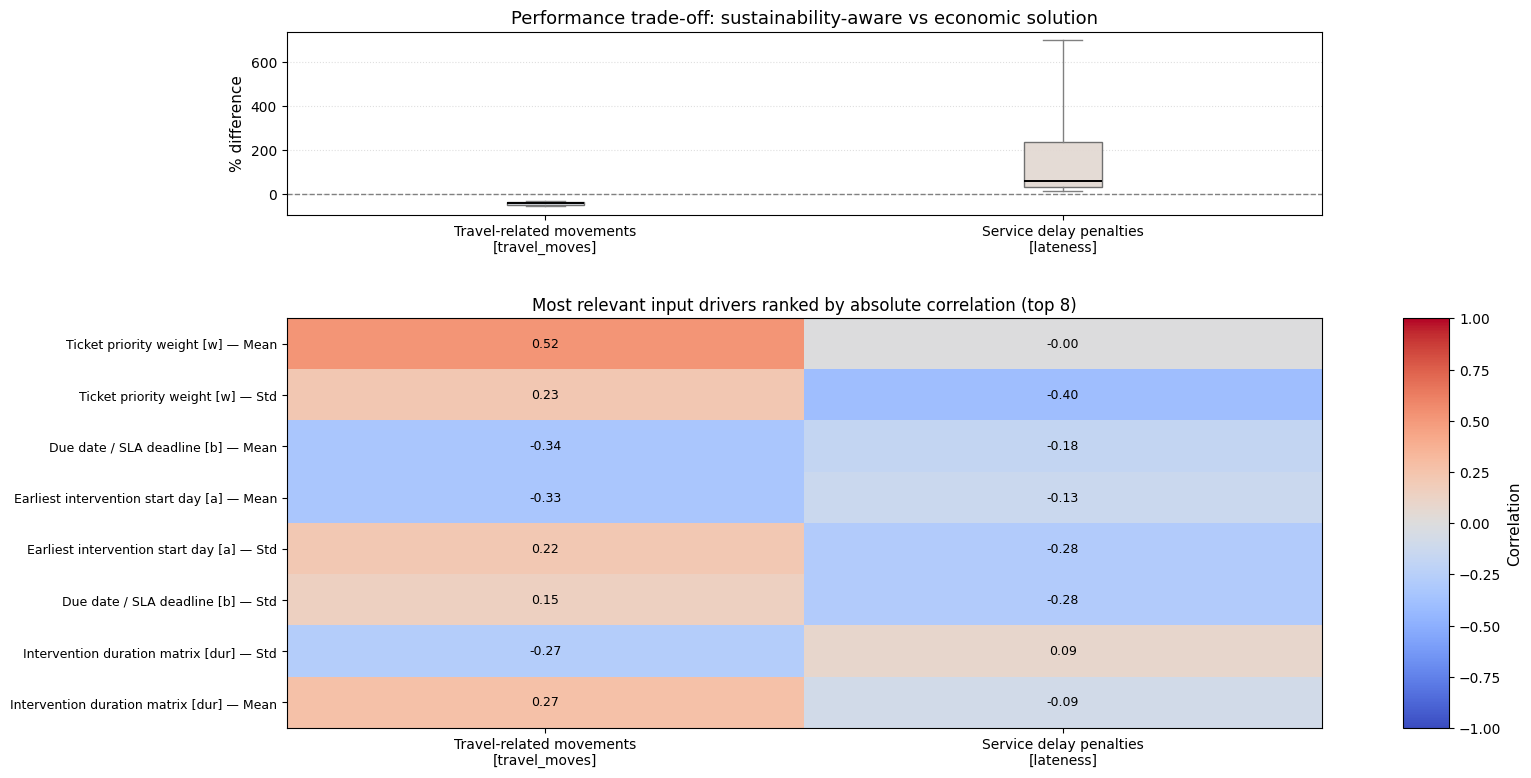

In [108]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors, cm


# =================================================
# PATHS
# =================================================
RESULTS_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results")
INSTANCES_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\instances")


# =================================================
# SETTINGS
# =================================================
METRICS_TO_PLOT = ["travel_moves", "lateness"]

METRIC_LABELS = {
    "work_days": "Technician work days",
    "travel_moves": "Travel-related movements",
    "hotel_days": "Hotel stay days",
    "idle_away_days": "Idle-away days",
    "lateness": "Service delay penalties",
}

INSTANCE_FEATURE_LABELS = {
    "a": "Earliest intervention start day",
    "b": "Due date / SLA deadline",
    "w": "Ticket priority weight",
    "dur": "Intervention duration matrix",
    "dist": "Travel distance matrix",
    "tt": "Travel time matrix",
    "Hkp": "Hotel activation matrix",
    "meta": "Meta information",
    "node": "Intervention location mapping",
    "base": "Technician home base",
    "EF": "Emission factor by travel mode",
    "emission": "Travel emission matrix",
    "co2": "Travel emission matrix",
    "cost": "Cost matrix",
    "travel_cost": "Travel cost matrix",
    "hotel_cost": "Hotel cost vector",
    "idle_cost": "Idle-away cost vector",
    "late_penalty": "Delay penalty vector",
    "penalty": "Penalty vector",
    "demand": "Demand vector",
    "workload": "Workload vector",
    "service_time": "Service time vector",
    "processing_time": "Processing time vector",
    "c_hotel": "Hotel daily cost",
    "c_idle_away": "Idle-away daily cost",
    "X": "Maximum consecutive days away",
    "alpha": "Weight of work term",
    "beta": "Weight of travel/emission term",
    "eta": "Weight of hotel term",
    "gamma": "Weight of lateness term",
    "delta": "Weight of idle-away term",
}

STAT_LABELS = {
    "Mean value": "Mean",
    "Standard deviation": "Std",
}

EXCLUDED_INSTANCE_KEYS = {
    "base",
    "tech_base",
    "technicians",
    "tasks",
    "nodes",
    "customers",
    "days",
    "modes",
    "skills",
    "skill",
    "name",
    "seed",
}

TOP_N_DRIVERS = 8
MIN_ABS_CORRELATION = 0.15


# =================================================
# BASIC UTILITIES
# =================================================
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def safe_variables(data):
    return data.get("variables", {})


def safe_corr(x, y):
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)

    valid = x.notna() & y.notna()
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan

    return x.corr(y)


def is_number(x):
    return isinstance(x, (int, float, np.integer, np.floating)) and not isinstance(x, bool)


def summarize_values(values):
    values = pd.Series(values, dtype=float).dropna()
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return float(values.mean()), np.nan
    return float(values.mean()), float(values.std(ddof=1))


def prettify_name(name):
    return str(name).replace("_", " ").strip().title()


# =================================================
# LABEL FORMATTERS
# =================================================
def format_label_with_symbol(symbol, label_map):
    meaning = label_map.get(symbol, prettify_name(symbol))
    return f"{meaning}\n[{symbol}]"


def format_metric_name(metric_key):
    return format_label_with_symbol(metric_key, METRIC_LABELS)


def format_feature_title(feature_key):
    meaning = INSTANCE_FEATURE_LABELS.get(feature_key, prettify_name(feature_key))
    return f"{meaning} [{feature_key}]"


def format_driver_label(feature_key, feature_stat):
    stat_short = STAT_LABELS.get(feature_stat, feature_stat)
    return f"{format_feature_title(feature_key)} — {stat_short}"


# =================================================
# FILE MATCHING
# =================================================
def collect_seed_files(results_dir, instances_dir):
    economic_files = {}
    sustainability_files = {}
    instance_files = {}

    for path in results_dir.iterdir():
        if not path.is_file():
            continue

        match_economic = re.fullmatch(r"economic_baseline_seed(\d+)\.json", path.name)
        if match_economic:
            economic_files[match_economic.group(1)] = path
            continue

        match_sustainable = re.fullmatch(r"sustainability_aware_seed(\d+)\.json", path.name)
        if match_sustainable:
            sustainability_files[match_sustainable.group(1)] = path

    for path in instances_dir.iterdir():
        if not path.is_file():
            continue

        match_instance = re.fullmatch(r"demo_clustered_seed(\d+)\.json", path.name)
        if match_instance:
            instance_files[match_instance.group(1)] = path

    common_seeds = sorted(
        set(economic_files) & set(sustainability_files) & set(instance_files),
        key=int
    )

    if not common_seeds:
        raise FileNotFoundError(
            "No matching triplets found:\n"
            "  economic_baseline_seedX.json\n"
            "  sustainability_aware_seedX.json\n"
            "  demo_clustered_seedX.json"
        )

    print("Matched triplets:")
    for seed in common_seeds:
        print(
            f"Seed {seed}: "
            f"{economic_files[seed].name} <-> "
            f"{sustainability_files[seed].name} <-> "
            f"{instance_files[seed].name}"
        )

    return common_seeds, economic_files, sustainability_files, instance_files


# =================================================
# SOLUTION METRICS
# =================================================
def extract_solution_metrics(vars_dict):
    z = vars_dict.get("z", {})
    y = vars_dict.get("y", {})
    hotel = vars_dict.get("hotel", {})
    idle_away = vars_dict.get("idle_away", {})
    lateness = vars_dict.get("L", {})

    return {
        "work_days": len(z),
        "travel_moves": len(y),
        "hotel_days": len(hotel),
        "idle_away_days": len(idle_away),
        "lateness": sum(float(v) for v in lateness.values()) if lateness else 0.0,
    }


def compute_percentage_change(economic_value, sustainable_value):
    economic_value = float(economic_value)
    sustainable_value = float(sustainable_value)

    if abs(economic_value) < 1e-12:
        return np.nan

    return 100.0 * (sustainable_value - economic_value) / economic_value


# =================================================
# INSTANCE FEATURE EXTRACTION
# =================================================
def collect_numeric_scalars(obj):
    values = []

    if is_number(obj):
        values.append(float(obj))
    elif isinstance(obj, dict):
        for nested_value in obj.values():
            values.extend(collect_numeric_scalars(nested_value))
    elif isinstance(obj, (list, tuple)):
        for nested_value in obj:
            values.extend(collect_numeric_scalars(nested_value))

    return values


def extract_instance_distribution_features(instance_data, min_count=2):
    feature_rows = {}

    for key, value in instance_data.items():
        if key in EXCLUDED_INSTANCE_KEYS:
            continue

        numeric_values = collect_numeric_scalars(value)

        if len(numeric_values) < min_count:
            continue

        mean_value, std_value = summarize_values(numeric_values)

        feature_rows[key] = {
            "mean": mean_value,
            "std": std_value,
            "count": len(numeric_values),
        }

    return feature_rows


# =================================================
# TABLE BUILDING
# =================================================
def build_analysis_tables(common_seeds, economic_files, sustainability_files, instance_files):
    seed_rows = []
    instance_feature_rows = []

    all_metrics = ["work_days", "travel_moves", "hotel_days", "idle_away_days", "lateness"]

    for seed in common_seeds:
        economic_data = load_json(economic_files[seed])
        sustainable_data = load_json(sustainability_files[seed])
        instance_data = load_json(instance_files[seed])

        economic_vars = safe_variables(economic_data)
        sustainable_vars = safe_variables(sustainable_data)

        economic_metrics = extract_solution_metrics(economic_vars)
        sustainable_metrics = extract_solution_metrics(sustainable_vars)

        seed_row = {"seed": int(seed)}
        for metric_name in all_metrics:
            economic_value = economic_metrics[metric_name]
            sustainable_value = sustainable_metrics[metric_name]

            seed_row[f"economic_{metric_name}"] = economic_value
            seed_row[f"sustainable_{metric_name}"] = sustainable_value
            seed_row[f"diff_pct_{metric_name}"] = compute_percentage_change(
                economic_value,
                sustainable_value
            )

        seed_rows.append(seed_row)

        feature_summary = extract_instance_distribution_features(instance_data)

        feature_row = {"seed": int(seed)}
        for feature_name, stats in feature_summary.items():
            feature_row[f"{feature_name}__mean"] = stats["mean"]
            feature_row[f"{feature_name}__std"] = stats["std"]
            feature_row[f"{feature_name}__count"] = stats["count"]

        instance_feature_rows.append(feature_row)

    seed_df = pd.DataFrame(seed_rows).sort_values("seed").reset_index(drop=True)
    feature_df = pd.DataFrame(instance_feature_rows).sort_values("seed").reset_index(drop=True)

    diff_pct = seed_df[[f"diff_pct_{metric}" for metric in METRICS_TO_PLOT]].copy()
    diff_pct.columns = METRICS_TO_PLOT

    merged_df = seed_df.merge(feature_df, on="seed", how="left")

    return seed_df, diff_pct, merged_df


# =================================================
# CORRELATION BUILDING
# =================================================
def build_feature_correlation_tables(metrics, merged_df):
    suffix_mean = "__mean"
    suffix_std = "__std"

    mean_columns = [column for column in merged_df.columns if column.endswith(suffix_mean)]
    ranking_rows = []

    for mean_column in mean_columns:
        feature_name = mean_column[:-len(suffix_mean)]
        std_column = f"{feature_name}{suffix_std}"

        if std_column not in merged_df.columns:
            continue

        mean_series = merged_df[mean_column]
        std_series = merged_df[std_column]

        for metric_name in metrics:
            metric_series = merged_df[f"diff_pct_{metric_name}"]

            correlation_mean = safe_corr(metric_series, mean_series)
            correlation_std = safe_corr(metric_series, std_series)

            ranking_rows.append({
                "feature_family": feature_name,
                "feature_family_label": format_feature_title(feature_name),
                "feature_stat": "Mean value",
                "metric": metric_name,
                "metric_label": METRIC_LABELS.get(metric_name, prettify_name(metric_name)),
                "correlation": correlation_mean,
                "abs_correlation": abs(correlation_mean) if pd.notna(correlation_mean) else np.nan,
            })

            ranking_rows.append({
                "feature_family": feature_name,
                "feature_family_label": format_feature_title(feature_name),
                "feature_stat": "Standard deviation",
                "metric": metric_name,
                "metric_label": METRIC_LABELS.get(metric_name, prettify_name(metric_name)),
                "correlation": correlation_std,
                "abs_correlation": abs(correlation_std) if pd.notna(correlation_std) else np.nan,
            })

    ranking_df = pd.DataFrame(ranking_rows)

    if not ranking_df.empty:
        ranking_df = ranking_df.sort_values(
            ["abs_correlation", "feature_family_label", "feature_stat", "metric_label"],
            ascending=[False, True, True, True]
        ).reset_index(drop=True)

    return ranking_df


def build_ranked_heatmap_table(ranking_df, metrics, top_n=None, min_abs_corr=None):
    if ranking_df.empty:
        return pd.DataFrame()

    filtered_df = ranking_df[ranking_df["metric"].isin(metrics)].copy()

    filtered_df["row_label"] = filtered_df.apply(
        lambda row: format_driver_label(row["feature_family"], row["feature_stat"]),
        axis=1
    )

    heatmap_df = filtered_df.pivot_table(
        index="row_label",
        columns="metric",
        values="correlation",
        aggfunc="first"
    )

    heatmap_df = heatmap_df.reindex(columns=metrics)

    row_strength = heatmap_df.abs().max(axis=1)

    if min_abs_corr is not None:
        strong_rows = row_strength[row_strength >= min_abs_corr].index
        heatmap_df = heatmap_df.loc[strong_rows]
        row_strength = row_strength.loc[strong_rows]

    heatmap_df = heatmap_df.loc[row_strength.sort_values(ascending=False).index]

    if top_n is not None:
        heatmap_df = heatmap_df.head(top_n)

    return heatmap_df


# =================================================
# PLOT
# =================================================
def plot_results(metrics, diff_pct, ranking_df, top_n=10, min_abs_corr=0.15):
    cmap = plt.get_cmap("coolwarm")
    heat_norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    box_data = [diff_pct[metric].dropna().values.astype(float) for metric in metrics]
    valid_box_data = [values for values in box_data if len(values) > 0]

    if not valid_box_data:
        raise ValueError("No valid boxplot data available.")

    box_abs_max = max(np.nanmax(np.abs(values)) for values in valid_box_data)
    box_abs_max = max(box_abs_max, 1e-9)
    box_norm = colors.TwoSlopeNorm(vmin=-box_abs_max, vcenter=0, vmax=box_abs_max)

    metric_labels = [format_metric_name(metric) for metric in metrics]

    ranked_heatmap = build_ranked_heatmap_table(
        ranking_df=ranking_df,
        metrics=metrics,
        top_n=top_n,
        min_abs_corr=min_abs_corr
    )

    if ranked_heatmap.empty:
        raise ValueError("No valid ranked heatmap data after filtering.")

    display_heatmap = ranked_heatmap.copy()
    display_heatmap.columns = metric_labels

    n_driver_rows = display_heatmap.shape[0]
    figure_height = 5.2 + 0.48 * n_driver_rows

    fig = plt.figure(figsize=(15, figure_height))
    gs = fig.add_gridspec(
        2,
        2,
        height_ratios=[1.0, max(1.8, 0.28 * n_driver_rows)],
        width_ratios=[1.0, 0.045],
        hspace=0.35,
        wspace=0.15
    )

    # ---------------- TOP: BOXPLOT ----------------
    ax_top = fig.add_subplot(gs[0, 0])

    boxplot = ax_top.boxplot(
        box_data,
        labels=metric_labels,
        patch_artist=True,
        showfliers=False,
        whis=(5, 95)
    )

    for patch, values in zip(boxplot["boxes"], box_data):
        median_value = np.nanmedian(values) if len(values) > 0 else 0.0
        patch.set_facecolor(cmap(box_norm(median_value)))
        patch.set_edgecolor("dimgray")
        patch.set_linewidth(1.0)
        patch.set_alpha(0.95)

    for median in boxplot["medians"]:
        median.set_color("black")
        median.set_linewidth(1.4)

    for whisker in boxplot["whiskers"]:
        whisker.set_color("gray")
        whisker.set_linewidth(1.0)

    for cap in boxplot["caps"]:
        cap.set_color("gray")
        cap.set_linewidth(1.0)

    ax_top.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax_top.set_title(
        "Performance trade-off: sustainability-aware vs economic solution",
        fontsize=13
    )
    ax_top.set_ylabel("% difference", fontsize=11)
    ax_top.tick_params(axis="x", rotation=0, labelsize=10)
    ax_top.grid(axis="y", linestyle=":", alpha=0.4)

    ax_top_empty = fig.add_subplot(gs[0, 1])
    ax_top_empty.axis("off")

    # ---------------- BOTTOM: RANKED HEATMAP ----------------
    ax_heat = fig.add_subplot(gs[1, 0])

    image = ax_heat.imshow(
        display_heatmap.values.astype(float),
        cmap=cmap,
        norm=heat_norm,
        aspect="auto"
    )

    ax_heat.set_xticks(np.arange(display_heatmap.shape[1]))
    ax_heat.set_xticklabels(display_heatmap.columns, rotation=0, fontsize=10)

    ax_heat.set_yticks(np.arange(display_heatmap.shape[0]))
    ax_heat.set_yticklabels(display_heatmap.index, fontsize=9)

    ax_heat.set_title(
        f"Most relevant input drivers ranked by absolute correlation (top {display_heatmap.shape[0]})",
        fontsize=12
    )

    for row_idx in range(display_heatmap.shape[0]):
        for col_idx in range(display_heatmap.shape[1]):
            value = display_heatmap.iloc[row_idx, col_idx]
            label = "NaN" if pd.isna(value) else f"{value:.2f}"
            ax_heat.text(col_idx, row_idx, label, ha="center", va="center", fontsize=9)

    cax = fig.add_subplot(gs[1, 1])
    scalar_map = cm.ScalarMappable(norm=heat_norm, cmap=cmap)
    scalar_map.set_array([])
    colorbar = fig.colorbar(scalar_map, cax=cax)
    colorbar.set_label("Correlation", fontsize=11)

    plt.show()


# =================================================
# MAIN
# =================================================
common_seeds, economic_files, sustainability_files, instance_files = collect_seed_files(
    RESULTS_DIR,
    INSTANCES_DIR
)

seed_df, diff_pct, merged_df = build_analysis_tables(
    common_seeds,
    economic_files,
    sustainability_files,
    instance_files
)

ranking_df = build_feature_correlation_tables(
    metrics=METRICS_TO_PLOT,
    merged_df=merged_df
)

print("\nSeed-level % differences:")
print(diff_pct.round(2))

print("\nTop correlations by absolute value:")
if ranking_df.empty:
    print("No valid correlations found.")
else:
    print(
        ranking_df[
            [
                "feature_family_label",
                "feature_stat",
                "metric_label",
                "correlation",
                "abs_correlation",
            ]
        ]
        .round(3)
        .head(30)
        .to_string(index=False)
    )

ranked_heatmap_preview = build_ranked_heatmap_table(
    ranking_df=ranking_df,
    metrics=METRICS_TO_PLOT,
    top_n=TOP_N_DRIVERS,
    min_abs_corr=MIN_ABS_CORRELATION
)

print("\nSelected ranked drivers for visualization:")
if ranked_heatmap_preview.empty:
    print("No drivers passed the selected filters.")
else:
    for row_name in ranked_heatmap_preview.index:
        print(f" - {row_name}")

plot_results(
    metrics=METRICS_TO_PLOT,
    diff_pct=diff_pct,
    ranking_df=ranking_df,
    top_n=TOP_N_DRIVERS,
    min_abs_corr=MIN_ABS_CORRELATION
)


SEED-LEVEL VALUES USED IN THE BOXPLOT
    travel_moves  lateness
0        -52.660   366.667
1        -38.926   182.609
2        -58.462    22.917
3        -52.941   237.500
4        -47.953    76.190
5        -38.220  1150.000
6        -35.507     9.677
7        -44.295    34.043
8        -50.838   245.455
9        -54.922    50.000
10       -43.860    15.686
11       -48.077    29.545
12       -42.282    51.351
13       -53.695   700.000
14       -29.605   200.000
15       -59.804   333.333
16       -34.586    32.231
17       -44.242   130.769
18       -45.238   -27.119
19       -40.559    51.351
20       -56.757    57.812

DESCRIPTIVE STATISTICS OF BOXPLOT METRICS
      metric    mean  median     std     min      max  n
travel_moves -46.354 -45.238   8.355 -59.804  -29.605 21
    lateness 188.096  57.812 277.828 -27.119 1150.000 21

HEATMAP TABLE USED IN THE FIGURE
metric                                      travel_moves  lateness
row_label                                           

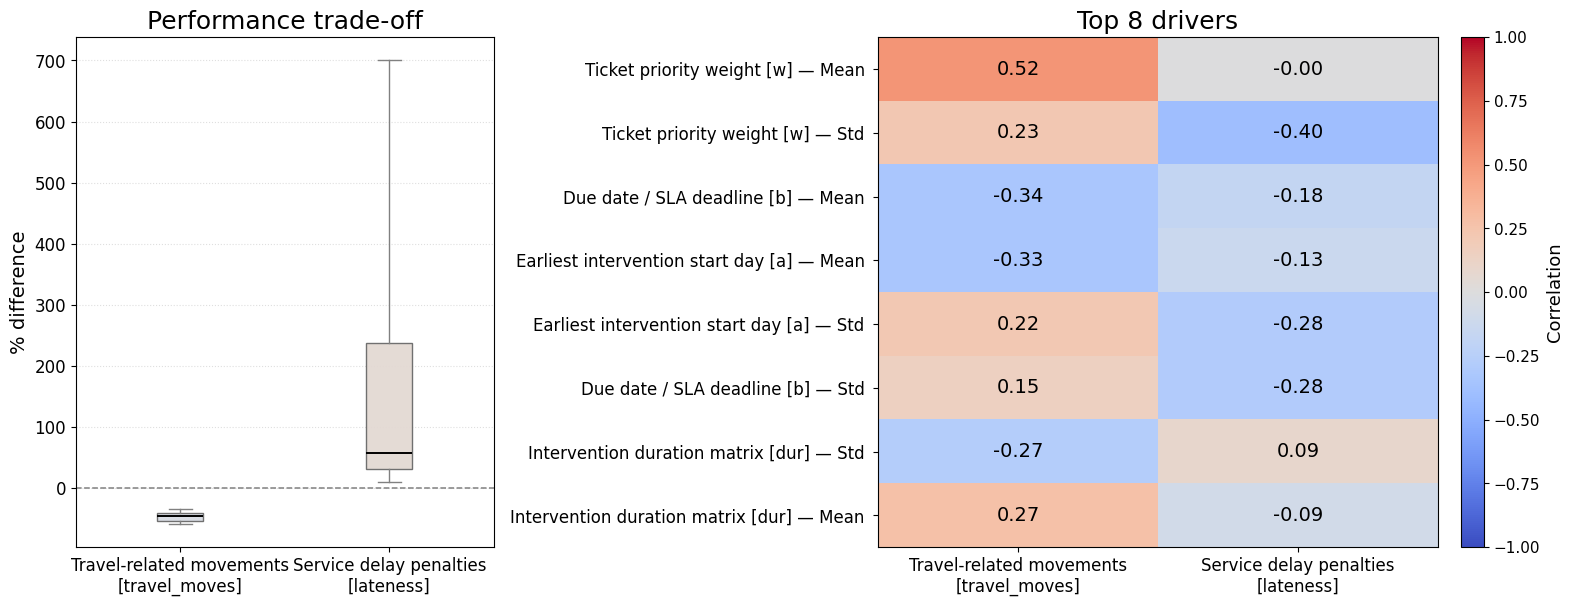

In [109]:
def run_plot_results(metrics, diff_pct, ranking_df, top_n=10, min_abs_corr=0.15):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib import colors, cm

    # -------------------------------------------------
    # STYLE
    # -------------------------------------------------
    cmap = plt.get_cmap("coolwarm")
    heat_norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    TITLE_SIZE = 18
    AXIS_LABEL_SIZE = 14
    BOX_TICK_SIZE = 12
    HEAT_X_SIZE = 12
    HEAT_Y_SIZE = 12
    CELL_TEXT_SIZE = 14
    COLORBAR_SIZE = 13

    # -------------------------------------------------
    # 1. PREPARE BOXPLOT DATA
    # -------------------------------------------------
    box_data = [diff_pct[metric].dropna().values.astype(float) for metric in metrics]
    valid_box_data = [values for values in box_data if len(values) > 0]

    if not valid_box_data:
        raise ValueError("No valid boxplot data available.")

    box_abs_max = max(np.nanmax(np.abs(values)) for values in valid_box_data)
    box_abs_max = max(box_abs_max, 1e-9)
    box_norm = colors.TwoSlopeNorm(vmin=-box_abs_max, vcenter=0, vmax=box_abs_max)

    metric_labels = [format_metric_name(metric) for metric in metrics]

    # -------------------------------------------------
    # 2. PREPARE HEATMAP DATA
    # -------------------------------------------------
    ranked_heatmap = build_ranked_heatmap_table(
        ranking_df,
        metrics,
        top_n,
        min_abs_corr
    )

    if ranked_heatmap.empty:
        raise ValueError("No valid ranked heatmap data after filtering.")

    display_heatmap = ranked_heatmap.copy()
    display_heatmap.columns = metric_labels

    # -------------------------------------------------
    # 3. PRINT TABLES FOR ANALYSIS
    # -------------------------------------------------
    print("\n" + "=" * 90)
    print("SEED-LEVEL VALUES USED IN THE BOXPLOT")
    print("=" * 90)
    boxplot_table = diff_pct[metrics].copy()
    print(boxplot_table.round(3).to_string(index=True))

    print("\n" + "=" * 90)
    print("DESCRIPTIVE STATISTICS OF BOXPLOT METRICS")
    print("=" * 90)
    summary_rows = []
    for metric in metrics:
        series = pd.Series(diff_pct[metric], dtype=float).dropna()
        summary_rows.append({
            "metric": metric,
            "mean": series.mean() if not series.empty else np.nan,
            "median": series.median() if not series.empty else np.nan,
            "std": series.std(ddof=1) if len(series) >= 2 else np.nan,
            "min": series.min() if not series.empty else np.nan,
            "max": series.max() if not series.empty else np.nan,
            "n": len(series),
        })
    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.round(3).to_string(index=False))

    print("\n" + "=" * 90)
    print("HEATMAP TABLE USED IN THE FIGURE")
    print("=" * 90)
    print(ranked_heatmap.round(3).to_string())

    # -------------------------------------------------
    # 4. CREATE FIGURE
    # -------------------------------------------------
    fig = plt.figure(figsize=(16, 7.5))

    outer_gs = fig.add_gridspec(
        1, 2,
        width_ratios=[1.00, 1.45],
        wspace=0.75
    )

    ax_box = fig.add_subplot(outer_gs[0, 0])

    right_gs = outer_gs[0, 1].subgridspec(
        1, 2,
        width_ratios=[1.0, 0.04],
        wspace=0.08
    )

    ax_heat = fig.add_subplot(right_gs[0, 0])
    cax = fig.add_subplot(right_gs[0, 1])

    # -------------------------------------------------
    # 5. LEFT PANEL: BOXPLOT
    # -------------------------------------------------
    boxplot = ax_box.boxplot(
        box_data,
        labels=metric_labels,
        patch_artist=True,
        showfliers=False,
        whis=(5, 95),
        widths=0.22
    )

    for patch, values in zip(boxplot["boxes"], box_data):
        median_value = np.nanmedian(values) if len(values) > 0 else 0.0
        patch.set_facecolor(cmap(box_norm(median_value)))
        patch.set_edgecolor("dimgray")
        patch.set_linewidth(1.0)
        patch.set_alpha(0.95)

    for median in boxplot["medians"]:
        median.set_color("black")
        median.set_linewidth(1.4)

    for whisker in boxplot["whiskers"]:
        whisker.set_color("gray")
        whisker.set_linewidth(1.0)

    for cap in boxplot["caps"]:
        cap.set_color("gray")
        cap.set_linewidth(1.0)

    ax_box.axhline(0, linestyle="--", linewidth=1.1, color="gray")
    ax_box.set_title("Performance trade-off", fontsize=TITLE_SIZE)
    ax_box.set_ylabel("% difference", fontsize=AXIS_LABEL_SIZE)
    ax_box.tick_params(axis="x", labelsize=BOX_TICK_SIZE)
    ax_box.tick_params(axis="y", labelsize=BOX_TICK_SIZE)
    ax_box.grid(axis="y", linestyle=":", alpha=0.4)

    # -------------------------------------------------
    # 6. RIGHT PANEL: HEATMAP
    # -------------------------------------------------
    image = ax_heat.imshow(
        display_heatmap.values.astype(float),
        cmap=cmap,
        norm=heat_norm,
        aspect="auto",
        interpolation="nearest"
    )

    ax_heat.set_xticks(np.arange(display_heatmap.shape[1]))
    ax_heat.set_xticklabels(display_heatmap.columns, fontsize=HEAT_X_SIZE)

    ax_heat.set_yticks(np.arange(display_heatmap.shape[0]))
    ax_heat.set_yticklabels(display_heatmap.index, fontsize=HEAT_Y_SIZE)

    ax_heat.tick_params(axis="y", pad=6)
    for label in ax_heat.get_yticklabels():
        label.set_horizontalalignment("right")

    ax_heat.set_title(f"Top {display_heatmap.shape[0]} drivers", fontsize=TITLE_SIZE)

    for row_idx in range(display_heatmap.shape[0]):
        for col_idx in range(display_heatmap.shape[1]):
            value = display_heatmap.iloc[row_idx, col_idx]
            text_label = "NaN" if pd.isna(value) else f"{value:.2f}"
            ax_heat.text(
                col_idx,
                row_idx,
                text_label,
                ha="center",
                va="center",
                fontsize=CELL_TEXT_SIZE,
                color="black"
            )

    # -------------------------------------------------
    # 7. COLORBAR
    # -------------------------------------------------
    scalar_map = cm.ScalarMappable(norm=heat_norm, cmap=cmap)
    scalar_map.set_array([])
    colorbar = fig.colorbar(scalar_map, cax=cax)
    colorbar.set_label("Correlation", fontsize=COLORBAR_SIZE)
    colorbar.ax.tick_params(labelsize=11)

    # -------------------------------------------------
    # 8. FINAL LAYOUT
    # -------------------------------------------------
    plt.subplots_adjust(
        left=0.08,
        right=0.96,
        top=0.88,
        bottom=0.20
    )
    plt.show()

    return {
        "boxplot_table": boxplot_table,
        "summary_table": summary_df,
        "heatmap_table": ranked_heatmap
    }


results_tables = run_plot_results(
    metrics=METRICS_TO_PLOT,
    diff_pct=diff_pct,
    ranking_df=ranking_df,
    top_n=TOP_N_DRIVERS,
    min_abs_corr=MIN_ABS_CORRELATION
)

## TECHNICIAN CHOICHE

Matched triplets:
Seed 10: economic_baseline_seed10.json <-> sustainability_aware_seed10.json <-> demo_clustered_seed10.json
Seed 11: economic_baseline_seed11.json <-> sustainability_aware_seed11.json <-> demo_clustered_seed11.json
Seed 12: economic_baseline_seed12.json <-> sustainability_aware_seed12.json <-> demo_clustered_seed12.json
Seed 18: economic_baseline_seed18.json <-> sustainability_aware_seed18.json <-> demo_clustered_seed18.json
Seed 19: economic_baseline_seed19.json <-> sustainability_aware_seed19.json <-> demo_clustered_seed19.json
Seed 20: economic_baseline_seed20.json <-> sustainability_aware_seed20.json <-> demo_clustered_seed20.json
Seed 21: economic_baseline_seed21.json <-> sustainability_aware_seed21.json <-> demo_clustered_seed21.json
Seed 22: economic_baseline_seed22.json <-> sustainability_aware_seed22.json <-> demo_clustered_seed22.json
Seed 23: economic_baseline_seed23.json <-> sustainability_aware_seed23.json <-> demo_clustered_seed23.json
Seed 33: economic_b

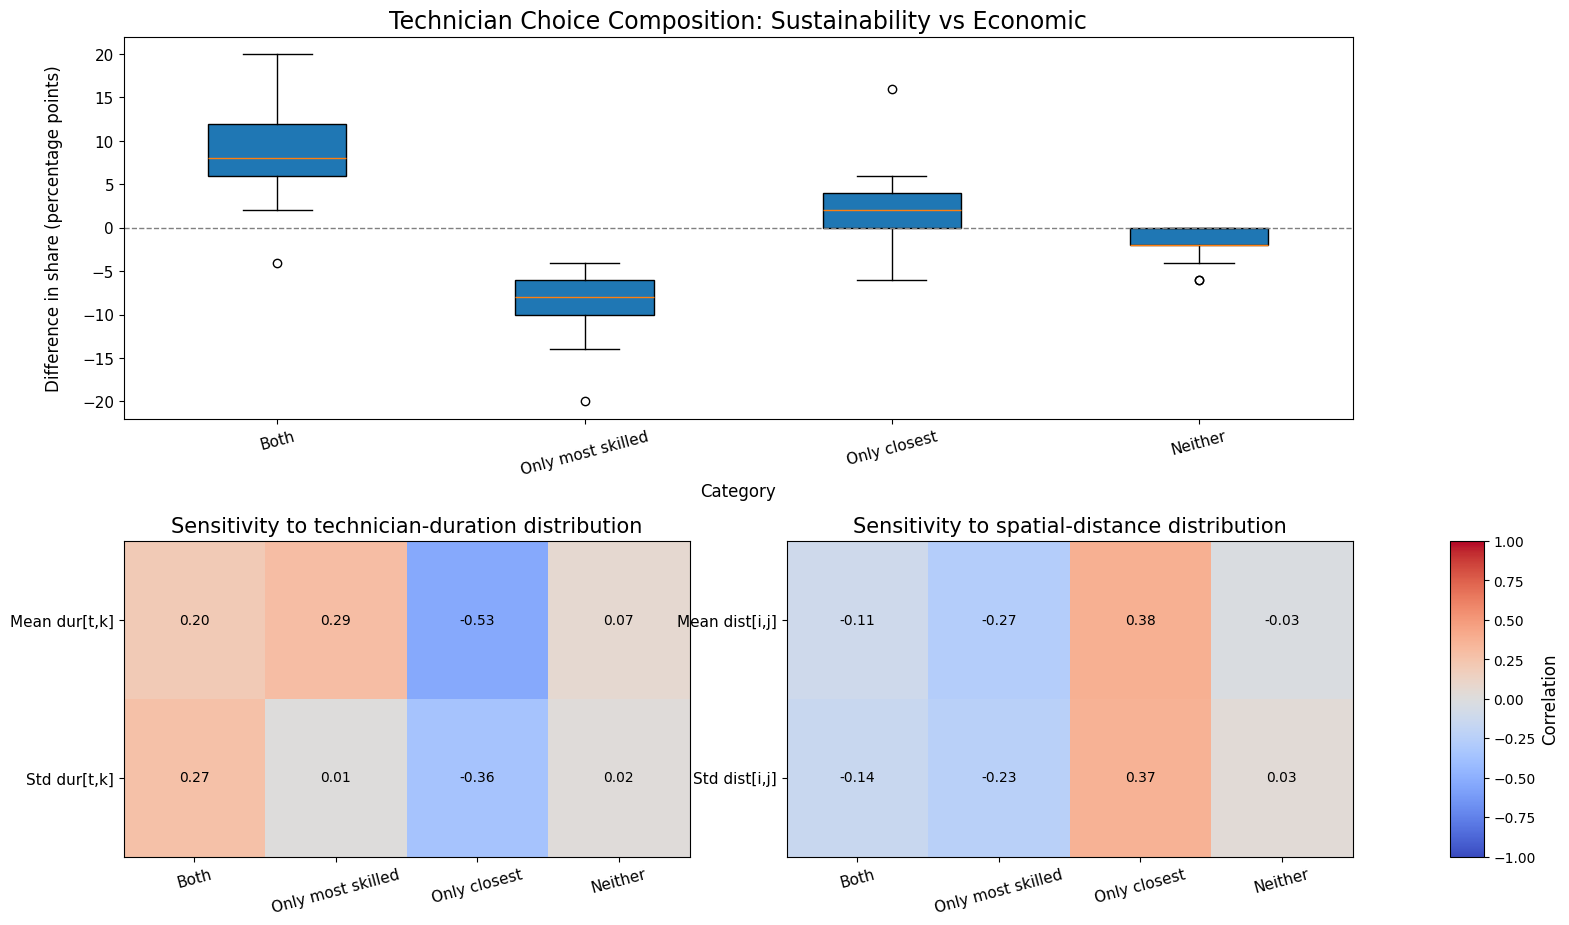

In [110]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =================================================
# PATHS
# =================================================
RESULTS_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results")
INSTANCES_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\instances")


# =================================================
# SETTINGS
# =================================================
USE_PERCENTAGE_POINTS = True
CATEGORY_ORDER = ["Both", "Only most skilled", "Only closest", "Neither"]


# =================================================
# BASIC HELPERS
# =================================================
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def split_key(key, expected_len=None):
    parts = str(key).split("|")
    if expected_len is not None and len(parts) != expected_len:
        return None
    return parts


def get_variables(data):
    return data.get("variables", {})


def safe_corr(x, y):
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)

    valid = x.notna() & y.notna()
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan

    return x.corr(y)


def get_nested_or_flat(data_dict, key1, key2, default=np.nan):
    if isinstance(data_dict.get(key1), dict) and key2 in data_dict[key1]:
        return float(data_dict[key1][key2])

    flat_key = f"{key1}|{key2}"
    if flat_key in data_dict:
        return float(data_dict[flat_key])

    return default


# =================================================
# MATCH FILES BY SEED
# =================================================
def collect_triplets(results_dir, instances_dir):
    economic_files = {}
    sustainability_files = {}
    instance_files = {}

    for path in results_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"economic_baseline_seed(\d+)\.json", path.name)
        if m:
            economic_files[m.group(1)] = path
            continue

        m = re.fullmatch(r"sustainability_aware_seed(\d+)\.json", path.name)
        if m:
            sustainability_files[m.group(1)] = path

    for path in instances_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"demo_clustered_seed(\d+)\.json", path.name)
        if m:
            instance_files[m.group(1)] = path

    common_seeds = sorted(
        set(economic_files) & set(sustainability_files) & set(instance_files),
        key=int
    )

    if not common_seeds:
        raise FileNotFoundError(
            "No matching triplets found:\n"
            "  economic_baseline_seedX.json\n"
            "  sustainability_aware_seedX.json\n"
            "  demo_clustered_seedX.json"
        )

    print("Matched triplets:")
    for seed in common_seeds:
        print(
            f"Seed {seed}: "
            f"{economic_files[seed].name} <-> "
            f"{sustainability_files[seed].name} <-> "
            f"{instance_files[seed].name}"
        )

    return common_seeds, economic_files, sustainability_files, instance_files


# =================================================
# CHOSEN TECHNICIAN
# =================================================
def get_chosen_technician(result_variables):
    chosen = {}
    start = result_variables.get("start", {})

    for key, value in start.items():
        if float(value) <= 0.5:
            continue

        parts = split_key(key, expected_len=3)  # ticket | tech | day
        if parts is None:
            continue

        ticket, tech, _day = parts
        chosen[ticket] = tech

    return chosen


# =================================================
# CLASSIFICATION
# =================================================
def classify_choice(chosen_tech, best_skill_set, closest_set):
    is_most_skilled = chosen_tech in best_skill_set
    is_closest = chosen_tech in closest_set

    if is_most_skilled and is_closest:
        return "Both"
    if is_most_skilled:
        return "Only most skilled"
    if is_closest:
        return "Only closest"
    return "Neither"


# =================================================
# INSTANCE FEATURES
# =================================================
def extract_instance_features(instance):
    tickets = list(instance.get("T", []))
    technicians = list(instance.get("K", []))
    nodes = list(instance.get("N", []))

    dur_data = instance.get("dur", {})
    dist_data = instance.get("dist", {})

    dur_vals = []
    for t in tickets:
        for k in technicians:
            val = get_nested_or_flat(dur_data, t, k, default=np.nan)
            if not pd.isna(val) and val != 999:
                dur_vals.append(float(val))

    dist_vals = []
    for i in nodes:
        for j in nodes:
            val = get_nested_or_flat(dist_data, i, j, default=np.nan)
            if not pd.isna(val):
                dist_vals.append(float(val))

    return {
        "mean_dur": float(np.mean(dur_vals)) if dur_vals else np.nan,
        "std_dur": float(np.std(dur_vals, ddof=1)) if len(dur_vals) >= 2 else np.nan,
        "mean_dist": float(np.mean(dist_vals)) if dist_vals else np.nan,
        "std_dist": float(np.std(dist_vals, ddof=1)) if len(dist_vals) >= 2 else np.nan,
    }


# =================================================
# PER-SEED CATEGORY DIFFERENCES
# =================================================
def compute_seed_category_differences(instance, econ_vars, sust_vars, use_percentage_points=True):
    tickets = list(instance.get("T", []))
    technicians = list(instance.get("K", []))
    ticket_node_map = instance.get("node", {})
    tech_base_map = instance.get("base", {})
    dist_data = instance.get("dist", {})
    dur_data = instance.get("dur", {})

    econ_choice = get_chosen_technician(econ_vars)
    sust_choice = get_chosen_technician(sust_vars)

    records = []

    for ticket in tickets:
        ticket_node = ticket_node_map.get(ticket)
        if ticket_node is None:
            continue

        skill_values = []
        distance_values = []

        for tech in technicians:
            tech_base = tech_base_map.get(tech)
            if tech_base is None:
                continue

            dur_val = get_nested_or_flat(dur_data, ticket, tech, default=np.nan)
            dist_val = get_nested_or_flat(dist_data, tech_base, ticket_node, default=np.nan)

            if not pd.isna(dur_val) and dur_val != 999:
                skill_values.append((tech, float(dur_val)))

            if not pd.isna(dist_val):
                distance_values.append((tech, float(dist_val)))

        if not skill_values or not distance_values:
            continue

        best_skill_value = min(v for _, v in skill_values)
        closest_value = min(v for _, v in distance_values)

        best_skill_set = {tech for tech, v in skill_values if abs(v - best_skill_value) <= 1e-9}
        closest_set = {tech for tech, v in distance_values if abs(v - closest_value) <= 1e-9}

        for scenario_name, scenario_choice in [("ECO", econ_choice), ("SUST", sust_choice)]:
            chosen_tech = scenario_choice.get(ticket)
            if chosen_tech is None:
                continue

            category = classify_choice(chosen_tech, best_skill_set, closest_set)

            records.append({
                "scenario": scenario_name,
                "ticket": ticket,
                "category": category
            })

    df = pd.DataFrame(records)

    if df.empty:
        return None, None, None

    summary_counts = (
        df.groupby(["scenario", "category"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=["ECO", "SUST"], columns=CATEGORY_ORDER, fill_value=0)
    )

    summary_pct = summary_counts.div(summary_counts.sum(axis=1), axis=0) * 100.0

    diff_map = {}
    for cat in CATEGORY_ORDER:
        eco_val = summary_pct.loc["ECO", cat]
        sust_val = summary_pct.loc["SUST", cat]

        if use_percentage_points:
            diff = sust_val - eco_val
        else:
            diff = np.nan if abs(eco_val) < 1e-12 else (sust_val - eco_val) / eco_val * 100.0

        diff_map[cat] = diff

    return df, summary_pct, diff_map


# =================================================
# BUILD DATASET
# =================================================
def build_pair_dataset(common_seeds, economic_files, sustainability_files, instance_files):
    rows = []
    diff_by_category = {cat: [] for cat in CATEGORY_ORDER}

    for seed in common_seeds:
        econ = load_json(economic_files[seed])
        sust = load_json(sustainability_files[seed])
        instance = load_json(instance_files[seed])

        econ_vars = get_variables(econ)
        sust_vars = get_variables(sust)

        features = extract_instance_features(instance)

        detail_df, summary_pct, diff_map = compute_seed_category_differences(
            instance,
            econ_vars,
            sust_vars,
            use_percentage_points=USE_PERCENTAGE_POINTS
        )

        if detail_df is None or summary_pct is None or diff_map is None:
            print(f"Seed {seed}: no assignments found, skipped.")
            continue

        print(f"\nSeed {seed} - percentage composition:")
        print(summary_pct.round(2))

        row = {"seed": int(seed)}
        row.update(features)

        for cat in CATEGORY_ORDER:
            row[cat] = diff_map[cat]
            if not pd.isna(diff_map[cat]):
                diff_by_category[cat].append(diff_map[cat])

        rows.append(row)

    pair_df = pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)

    if pair_df.empty:
        raise ValueError("No valid pair data available.")

    return pair_df, diff_by_category


# =================================================
# CORRELATION MATRICES
# =================================================
def build_correlation_matrices(pair_df, valid_categories):
    dur_features = ["mean_dur", "std_dur"]
    dist_features = ["mean_dist", "std_dist"]

    dur_corr = pd.DataFrame(index=dur_features, columns=valid_categories, dtype=float)
    dist_corr = pd.DataFrame(index=dist_features, columns=valid_categories, dtype=float)

    for feat in dur_features:
        for cat in valid_categories:
            dur_corr.loc[feat, cat] = safe_corr(pair_df[feat], pair_df[cat])

    for feat in dist_features:
        for cat in valid_categories:
            dist_corr.loc[feat, cat] = safe_corr(pair_df[feat], pair_df[cat])

    return dur_corr, dist_corr


# =================================================
# HEATMAP ANNOTATION
# =================================================
def annotate_heatmap(ax, df, fontsize=10):
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            val = df.iloc[i, j]
            txt = "NaN" if pd.isna(val) else f"{val:.2f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=fontsize)


# =================================================
# PLOT
# =================================================
def plot_results(valid_categories, boxplot_data, dur_corr, dist_corr):
    fig = plt.figure(figsize=(17, 10))
    gs = fig.add_gridspec(
        2, 3,
        height_ratios=[1.15, 0.95],
        width_ratios=[1, 1, 0.06],
        hspace=0.35,
        wspace=0.25
    )

    # ---------------- TOP: BOXPLOT ----------------
    ax_top = fig.add_subplot(gs[0, :2])

    clean_data = []
    clean_labels = []

    for cat, values in zip(valid_categories, boxplot_data):
        arr = np.asarray(values, dtype=float)
        arr = arr[~np.isnan(arr)]
        if arr.size == 0:
            continue
        clean_data.append(arr)
        clean_labels.append(cat)

    if not clean_data:
        raise ValueError("No valid category differences available for boxplot.")

    ax_top.boxplot(clean_data, labels=clean_labels, patch_artist=True)
    ax_top.axhline(0, linestyle="--", linewidth=1, color="gray")

    ylabel = (
        "Difference in share (percentage points)"
        if USE_PERCENTAGE_POINTS
        else "% Difference vs Economic"
    )

    ax_top.set_ylabel(ylabel, fontsize=12, labelpad=14)
    ax_top.set_xlabel("Category", fontsize=12)
    ax_top.set_title("Technician Choice Composition: Sustainability vs Economic", fontsize=17)
    ax_top.tick_params(axis="x", rotation=15, labelsize=11)
    ax_top.tick_params(axis="y", labelsize=11)

    # ---------------- BOTTOM LEFT: DUR ----------------
    ax1 = fig.add_subplot(gs[1, 0])

    dur_plot = dur_corr.astype(float)
    im1 = ax1.imshow(dur_plot.values, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
    ax1.set_xticks(np.arange(dur_plot.shape[1]))
    ax1.set_xticklabels(list(dur_plot.columns), rotation=15, fontsize=11)
    ax1.set_yticks(np.arange(dur_plot.shape[0]))
    ax1.set_yticklabels(["Mean dur[t,k]", "Std dur[t,k]"], fontsize=11)
    ax1.set_title("Sensitivity to technician-duration distribution", fontsize=15)

    annotate_heatmap(ax1, dur_plot, fontsize=10)

    # ---------------- BOTTOM RIGHT: DIST ----------------
    ax2 = fig.add_subplot(gs[1, 1])

    dist_plot = dist_corr.astype(float)
    im2 = ax2.imshow(dist_plot.values, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
    ax2.set_xticks(np.arange(dist_plot.shape[1]))
    ax2.set_xticklabels(list(dist_plot.columns), rotation=15, fontsize=11)
    ax2.set_yticks(np.arange(dist_plot.shape[0]))
    ax2.set_yticklabels(["Mean dist[i,j]", "Std dist[i,j]"], fontsize=11)
    ax2.set_title("Sensitivity to spatial-distance distribution", fontsize=15)

    annotate_heatmap(ax2, dist_plot, fontsize=10)

    # ---------------- COLORBAR ----------------
    cax = fig.add_subplot(gs[1, 2])
    cbar = fig.colorbar(im2, cax=cax)
    cbar.set_label("Correlation", fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    # ---------------- FINAL SPACING ----------------
    fig.subplots_adjust(
        left=0.12,
        right=0.92,
        top=0.92,
        bottom=0.10
    )

    plt.show()


# =================================================
# MAIN
# =================================================
common_seeds, economic_files, sustainability_files, instance_files = collect_triplets(
    RESULTS_DIR,
    INSTANCES_DIR
)

pair_df, diff_by_category = build_pair_dataset(
    common_seeds,
    economic_files,
    sustainability_files,
    instance_files
)

print("\nPer-seed dataset:")
print(pair_df.round(3))

valid_categories = [cat for cat in CATEGORY_ORDER if len(diff_by_category[cat]) > 0]
if not valid_categories:
    raise ValueError("No valid category differences could be computed.")

boxplot_data = [diff_by_category[cat] for cat in valid_categories]

print("\nDifferences by category:")
for cat in valid_categories:
    print(f"{cat}: {[round(v, 2) for v in diff_by_category[cat]]}")

dur_corr, dist_corr = build_correlation_matrices(pair_df, valid_categories)

print("\nCorrelation matrix - dur features:")
print(dur_corr.round(3))

print("\nCorrelation matrix - dist features:")
print(dist_corr.round(3))

plot_results(valid_categories, boxplot_data, dur_corr, dist_corr)

Matched triplets:
Seed 10: economic_baseline_seed10.json <-> sustainability_aware_seed10.json <-> demo_clustered_seed10.json
Seed 11: economic_baseline_seed11.json <-> sustainability_aware_seed11.json <-> demo_clustered_seed11.json
Seed 12: economic_baseline_seed12.json <-> sustainability_aware_seed12.json <-> demo_clustered_seed12.json
Seed 18: economic_baseline_seed18.json <-> sustainability_aware_seed18.json <-> demo_clustered_seed18.json
Seed 19: economic_baseline_seed19.json <-> sustainability_aware_seed19.json <-> demo_clustered_seed19.json
Seed 20: economic_baseline_seed20.json <-> sustainability_aware_seed20.json <-> demo_clustered_seed20.json
Seed 21: economic_baseline_seed21.json <-> sustainability_aware_seed21.json <-> demo_clustered_seed21.json
Seed 22: economic_baseline_seed22.json <-> sustainability_aware_seed22.json <-> demo_clustered_seed22.json
Seed 23: economic_baseline_seed23.json <-> sustainability_aware_seed23.json <-> demo_clustered_seed23.json
Seed 33: economic_b

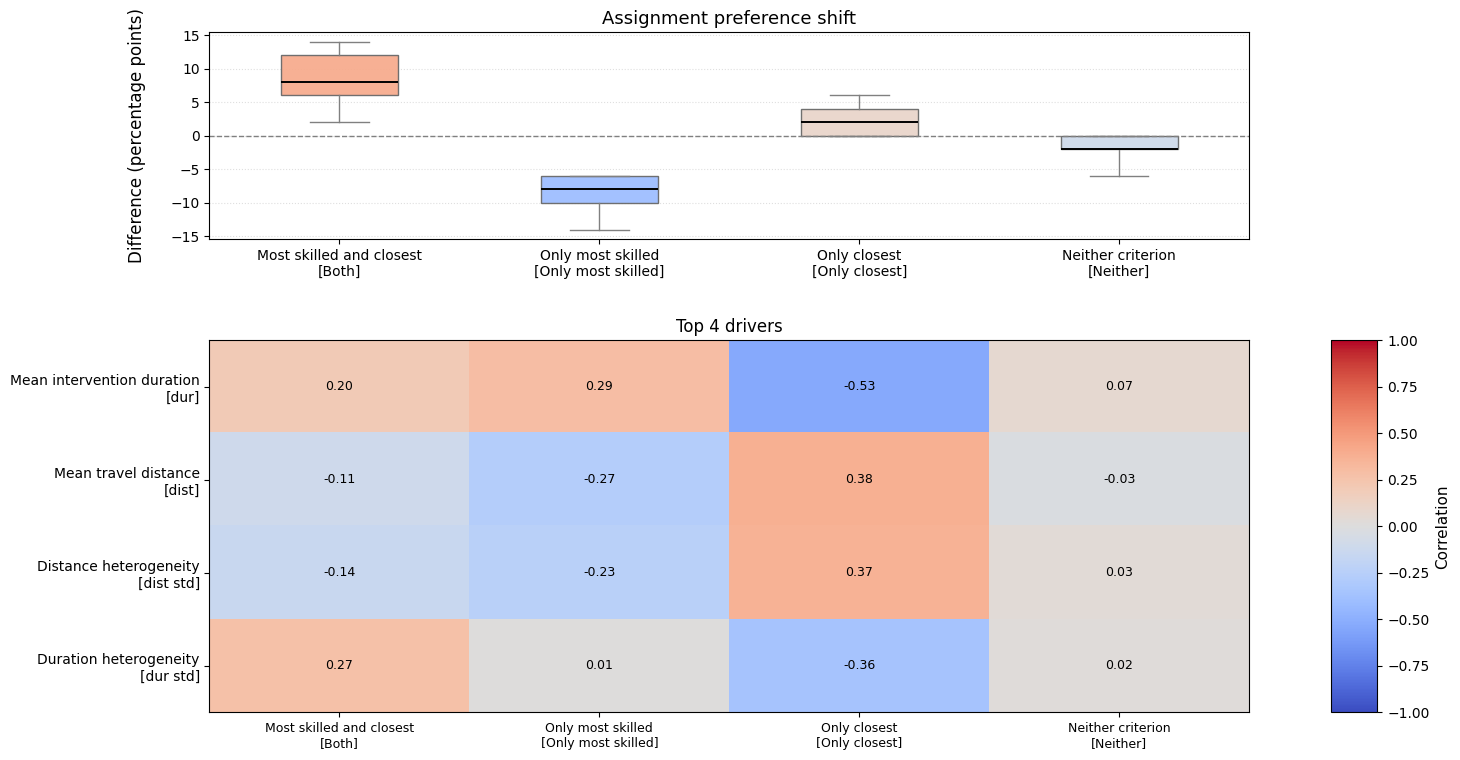

In [111]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors, cm


# =================================================
# PATHS
# =================================================
RESULTS_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results")
INSTANCES_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\instances")


# =================================================
# SETTINGS
# =================================================
USE_PERCENTAGE_POINTS = True
CATEGORY_ORDER = ["Both", "Only most skilled", "Only closest", "Neither"]

CATEGORY_LABELS = {
    "Both": "Most skilled and closest\n[Both]",
    "Only most skilled": "Only most skilled\n[Only most skilled]",
    "Only closest": "Only closest\n[Only closest]",
    "Neither": "Neither criterion\n[Neither]",
}

FEATURE_LABELS = {
    "mean_dur": "Mean intervention duration\n[dur]",
    "std_dur": "Duration heterogeneity\n[dur std]",
    "mean_dist": "Mean travel distance\n[dist]",
    "std_dist": "Distance heterogeneity\n[dist std]",
}

TOP_N_DRIVERS = 8
MIN_ABS_CORRELATION = 0.10


# =================================================
# BASIC HELPERS
# =================================================
def load_json(path):
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def split_key(key, expected_len=None):
    parts = str(key).split("|")
    if expected_len is not None and len(parts) != expected_len:
        return None
    return parts


def get_variables(data):
    return data.get("variables", {})


def safe_corr(x, y):
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)

    valid_mask = x.notna() & y.notna()
    x = x[valid_mask]
    y = y[valid_mask]

    if len(x) < 2:
        return np.nan
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan

    return x.corr(y)


def get_nested_or_flat(data_dict, key1, key2, default=np.nan):
    if isinstance(data_dict.get(key1), dict) and key2 in data_dict[key1]:
        return float(data_dict[key1][key2])

    flat_key = f"{key1}|{key2}"
    if flat_key in data_dict:
        return float(data_dict[flat_key])

    return default


def prettify_name(name):
    return str(name).replace("_", " ").strip().title()


def format_category_name(category):
    return CATEGORY_LABELS.get(category, f"{category}\n[{category}]")


def format_feature_name(feature_key):
    return FEATURE_LABELS.get(feature_key, prettify_name(feature_key))


# =================================================
# MATCH FILES BY SEED
# =================================================
def collect_triplets(results_dir, instances_dir):
    if not results_dir.exists():
        raise FileNotFoundError(f"Results directory not found: {results_dir}")
    if not instances_dir.exists():
        raise FileNotFoundError(f"Instances directory not found: {instances_dir}")

    economic_files = {}
    sustainability_files = {}
    instance_files = {}

    for path in results_dir.iterdir():
        if not path.is_file():
            continue

        match_economic = re.fullmatch(r"economic_baseline_seed(\d+)\.json", path.name)
        if match_economic:
            economic_files[match_economic.group(1)] = path
            continue

        match_sustainable = re.fullmatch(r"sustainability_aware_seed(\d+)\.json", path.name)
        if match_sustainable:
            sustainability_files[match_sustainable.group(1)] = path

    for path in instances_dir.iterdir():
        if not path.is_file():
            continue

        match_instance = re.fullmatch(r"demo_clustered_seed(\d+)\.json", path.name)
        if match_instance:
            instance_files[match_instance.group(1)] = path

    common_seeds = sorted(
        set(economic_files) & set(sustainability_files) & set(instance_files),
        key=int
    )

    if not common_seeds:
        raise FileNotFoundError(
            "No matching triplets found:\n"
            "  economic_baseline_seedX.json\n"
            "  sustainability_aware_seedX.json\n"
            "  demo_clustered_seedX.json"
        )

    print("Matched triplets:")
    for seed in common_seeds:
        print(
            f"Seed {seed}: "
            f"{economic_files[seed].name} <-> "
            f"{sustainability_files[seed].name} <-> "
            f"{instance_files[seed].name}"
        )

    return common_seeds, economic_files, sustainability_files, instance_files


# =================================================
# CHOSEN TECHNICIAN
# =================================================
def get_chosen_technician(result_variables):
    chosen_by_ticket = {}
    start_variables = result_variables.get("start", {})

    for key, value in start_variables.items():
        if float(value) <= 0.5:
            continue

        parts = split_key(key, expected_len=3)
        if parts is None:
            continue

        ticket, technician, _day = parts
        chosen_by_ticket[ticket] = technician

    return chosen_by_ticket


# =================================================
# CLASSIFICATION
# =================================================
def classify_choice(chosen_technician, best_skill_set, closest_set):
    is_most_skilled = chosen_technician in best_skill_set
    is_closest = chosen_technician in closest_set

    if is_most_skilled and is_closest:
        return "Both"
    if is_most_skilled:
        return "Only most skilled"
    if is_closest:
        return "Only closest"
    return "Neither"


# =================================================
# INSTANCE FEATURES
# =================================================
def extract_instance_features(instance):
    tickets = list(instance.get("T", []))
    technicians = list(instance.get("K", []))
    nodes = list(instance.get("N", []))

    duration_data = instance.get("dur", {})
    distance_data = instance.get("dist", {})

    duration_values = []
    for ticket in tickets:
        for technician in technicians:
            value = get_nested_or_flat(duration_data, ticket, technician, default=np.nan)
            if not pd.isna(value) and value != 999:
                duration_values.append(float(value))

    distance_values = []
    for origin in nodes:
        for destination in nodes:
            value = get_nested_or_flat(distance_data, origin, destination, default=np.nan)
            if not pd.isna(value):
                distance_values.append(float(value))

    return {
        "mean_dur": float(np.mean(duration_values)) if duration_values else np.nan,
        "std_dur": float(np.std(duration_values, ddof=1)) if len(duration_values) >= 2 else np.nan,
        "mean_dist": float(np.mean(distance_values)) if distance_values else np.nan,
        "std_dist": float(np.std(distance_values, ddof=1)) if len(distance_values) >= 2 else np.nan,
    }


# =================================================
# PER-SEED CATEGORY DIFFERENCES
# =================================================
def compute_seed_category_differences(instance, economic_variables, sustainable_variables, use_percentage_points=True):
    tickets = list(instance.get("T", []))
    technicians = list(instance.get("K", []))
    ticket_node_map = instance.get("node", {})
    technician_base_map = instance.get("base", {})
    distance_data = instance.get("dist", {})
    duration_data = instance.get("dur", {})

    economic_choice = get_chosen_technician(economic_variables)
    sustainable_choice = get_chosen_technician(sustainable_variables)

    records = []

    for ticket in tickets:
        ticket_node = ticket_node_map.get(ticket)
        if ticket_node is None:
            continue

        skill_values = []
        distance_values = []

        for technician in technicians:
            technician_base = technician_base_map.get(technician)
            if technician_base is None:
                continue

            duration_value = get_nested_or_flat(duration_data, ticket, technician, default=np.nan)
            distance_value = get_nested_or_flat(distance_data, technician_base, ticket_node, default=np.nan)

            if not pd.isna(duration_value) and duration_value != 999:
                skill_values.append((technician, float(duration_value)))

            if not pd.isna(distance_value):
                distance_values.append((technician, float(distance_value)))

        if not skill_values or not distance_values:
            continue

        best_skill_value = min(value for _, value in skill_values)
        closest_value = min(value for _, value in distance_values)

        best_skill_set = {technician for technician, value in skill_values if abs(value - best_skill_value) <= 1e-9}
        closest_set = {technician for technician, value in distance_values if abs(value - closest_value) <= 1e-9}

        for scenario_name, scenario_choice in [("ECO", economic_choice), ("SUST", sustainable_choice)]:
            chosen_technician = scenario_choice.get(ticket)
            if chosen_technician is None:
                continue

            category = classify_choice(chosen_technician, best_skill_set, closest_set)

            records.append({
                "scenario": scenario_name,
                "ticket": ticket,
                "category": category,
            })

    detail_df = pd.DataFrame(records)

    if detail_df.empty:
        return None, None, None

    summary_counts = (
        detail_df.groupby(["scenario", "category"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=["ECO", "SUST"], columns=CATEGORY_ORDER, fill_value=0)
    )

    summary_percentages = summary_counts.div(summary_counts.sum(axis=1), axis=0) * 100.0

    diff_map = {}
    for category in CATEGORY_ORDER:
        economic_share = summary_percentages.loc["ECO", category]
        sustainable_share = summary_percentages.loc["SUST", category]

        if use_percentage_points:
            difference = sustainable_share - economic_share
        else:
            difference = (
                np.nan
                if abs(economic_share) < 1e-12
                else (sustainable_share - economic_share) / economic_share * 100.0
            )

        diff_map[category] = difference

    return detail_df, summary_percentages, diff_map


# =================================================
# BUILD DATASET
# =================================================
def build_pair_dataset(common_seeds, economic_files, sustainability_files, instance_files):
    rows = []
    difference_by_category = {category: [] for category in CATEGORY_ORDER}

    for seed in common_seeds:
        economic_data = load_json(economic_files[seed])
        sustainable_data = load_json(sustainability_files[seed])
        instance_data = load_json(instance_files[seed])

        economic_variables = get_variables(economic_data)
        sustainable_variables = get_variables(sustainable_data)

        instance_features = extract_instance_features(instance_data)

        detail_df, summary_percentages, diff_map = compute_seed_category_differences(
            instance_data,
            economic_variables,
            sustainable_variables,
            use_percentage_points=USE_PERCENTAGE_POINTS
        )

        if detail_df is None or summary_percentages is None or diff_map is None:
            print(f"Seed {seed}: no assignments found, skipped.")
            continue

        row = {"seed": int(seed)}
        row.update(instance_features)

        for category in CATEGORY_ORDER:
            row[category] = diff_map[category]
            if pd.notna(diff_map[category]):
                difference_by_category[category].append(diff_map[category])

        rows.append(row)

    pair_df = pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)

    if pair_df.empty:
        raise ValueError("No valid pair data available.")

    return pair_df, difference_by_category


# =================================================
# CORRELATION TABLE
# =================================================
def build_ranked_driver_table(pair_df, valid_categories):
    feature_keys = ["mean_dur", "std_dur", "mean_dist", "std_dist"]
    rows = []

    for feature_key in feature_keys:
        for category in valid_categories:
            correlation_value = safe_corr(pair_df[feature_key], pair_df[category])
            rows.append({
                "feature_key": feature_key,
                "feature_label": format_feature_name(feature_key),
                "category": category,
                "category_label": format_category_name(category),
                "correlation": correlation_value,
                "abs_correlation": abs(correlation_value) if pd.notna(correlation_value) else np.nan,
            })

    ranking_df = pd.DataFrame(rows)

    if not ranking_df.empty:
        ranking_df = ranking_df.sort_values(
            ["abs_correlation", "feature_label", "category"],
            ascending=[False, True, True]
        ).reset_index(drop=True)

    return ranking_df


def build_ranked_heatmap_table(ranking_df, valid_categories, top_n=None, min_abs_corr=None):
    if ranking_df.empty:
        return pd.DataFrame()

    heatmap_df = ranking_df.pivot_table(
        index="feature_label",
        columns="category",
        values="correlation",
        aggfunc="first"
    )

    heatmap_df = heatmap_df.reindex(columns=valid_categories)

    row_strength = heatmap_df.abs().max(axis=1)

    if min_abs_corr is not None:
        selected_rows = row_strength[row_strength >= min_abs_corr].index
        heatmap_df = heatmap_df.loc[selected_rows]
        row_strength = row_strength.loc[selected_rows]

    heatmap_df = heatmap_df.loc[row_strength.sort_values(ascending=False).index]

    if top_n is not None:
        heatmap_df = heatmap_df.head(top_n)

    return heatmap_df


# =================================================
# TABLES FOR CHAT ANALYSIS
# =================================================
def build_summary_statistics_table(pair_df, valid_categories):
    summary_rows = []

    for category in valid_categories:
        series = pd.Series(pair_df[category], dtype=float).dropna()

        if series.empty:
            continue

        summary_rows.append({
            "category": category,
            "mean": series.mean(),
            "median": series.median(),
            "std": series.std(ddof=1) if len(series) >= 2 else np.nan,
            "min": series.min(),
            "max": series.max(),
            "n": len(series),
        })

    summary_df = pd.DataFrame(summary_rows)
    return summary_df


def print_analysis_tables(pair_df, valid_categories, ranking_df, top_n, min_abs_corr):
    print("\n" + "=" * 80)
    print("SEED-LEVEL CATEGORY DIFFERENCES")
    print("=" * 80)
    seed_table = pair_df[["seed"] + valid_categories].copy()
    print(seed_table.round(3).to_string(index=False))

    print("\n" + "=" * 80)
    print("DESCRIPTIVE STATISTICS OF CATEGORY DIFFERENCES")
    print("=" * 80)
    summary_df = build_summary_statistics_table(pair_df, valid_categories)
    if summary_df.empty:
        print("No summary statistics available.")
    else:
        print(summary_df.round(3).to_string(index=False))

    print("\n" + "=" * 80)
    print("FULL CORRELATION TABLE")
    print("=" * 80)
    if ranking_df.empty:
        print("No valid correlations available.")
    else:
        print(
            ranking_df[
                ["feature_key", "feature_label", "category", "correlation", "abs_correlation"]
            ]
            .round(3)
            .to_string(index=False)
        )

    print("\n" + "=" * 80)
    print("HEATMAP TABLE USED FOR THE FIGURE")
    print("=" * 80)
    heatmap_df = build_ranked_heatmap_table(
        ranking_df=ranking_df,
        valid_categories=valid_categories,
        top_n=top_n,
        min_abs_corr=min_abs_corr
    )

    if heatmap_df.empty:
        print("No heatmap table available after filtering.")
    else:
        print(heatmap_df.round(3).to_string())

    return summary_df, heatmap_df


# =================================================
# PLOT
# =================================================
def plot_results(valid_categories, difference_by_category, ranking_df, top_n=8, min_abs_corr=0.10):
    cmap = plt.get_cmap("coolwarm")
    heat_norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    boxplot_data = []
    boxplot_labels = []

    for category in valid_categories:
        values = np.asarray(difference_by_category[category], dtype=float)
        values = values[~np.isnan(values)]
        if values.size == 0:
            continue
        boxplot_data.append(values)
        boxplot_labels.append(format_category_name(category))

    if not boxplot_data:
        raise ValueError("No valid category differences available for boxplot.")

    heatmap_df = build_ranked_heatmap_table(
        ranking_df=ranking_df,
        valid_categories=valid_categories,
        top_n=top_n,
        min_abs_corr=min_abs_corr
    )

    if heatmap_df.empty:
        raise ValueError("No valid ranked heatmap data after filtering.")

    display_heatmap = heatmap_df.copy()
    display_heatmap.columns = [format_category_name(column) for column in display_heatmap.columns]

    box_abs_max = max(np.nanmax(np.abs(values)) for values in boxplot_data)
    box_abs_max = max(box_abs_max, 1e-9)
    box_norm = colors.TwoSlopeNorm(vmin=-box_abs_max, vcenter=0, vmax=box_abs_max)

    n_driver_rows = display_heatmap.shape[0]
    figure_height = 5.6 + 0.60 * n_driver_rows

    fig = plt.figure(figsize=(16, figure_height), constrained_layout=False)
    gs = fig.add_gridspec(
        2,
        2,
        height_ratios=[1.0, max(1.8, 0.33 * n_driver_rows)],
        width_ratios=[1.0, 0.045],
        hspace=0.35,
        wspace=0.15
    )

    ax_top = fig.add_subplot(gs[0, 0])

    boxplot = ax_top.boxplot(
        boxplot_data,
        labels=boxplot_labels,
        patch_artist=True,
        showfliers=False,
        whis=(5, 95)
    )

    for patch, values in zip(boxplot["boxes"], boxplot_data):
        median_value = np.nanmedian(values) if len(values) > 0 else 0.0
        patch.set_facecolor(cmap(box_norm(median_value)))
        patch.set_edgecolor("dimgray")
        patch.set_linewidth(1.0)
        patch.set_alpha(0.95)

    for median in boxplot["medians"]:
        median.set_color("black")
        median.set_linewidth(1.4)

    for whisker in boxplot["whiskers"]:
        whisker.set_color("gray")
        whisker.set_linewidth(1.0)

    for cap in boxplot["caps"]:
        cap.set_color("gray")
        cap.set_linewidth(1.0)

    ax_top.axhline(0, linestyle="--", linewidth=1, color="gray")

    y_label = (
        "Difference (percentage points)"
        if USE_PERCENTAGE_POINTS
        else "% difference vs economic solution"
    )

    ax_top.set_title("Assignment preference shift", fontsize=13)
    ax_top.set_ylabel(y_label, fontsize=12, labelpad=18)
    ax_top.tick_params(axis="x", rotation=0, labelsize=10)
    ax_top.tick_params(axis="y", labelsize=10)
    ax_top.grid(axis="y", linestyle=":", alpha=0.4)

    ax_top_empty = fig.add_subplot(gs[0, 1])
    ax_top_empty.axis("off")

    ax_heat = fig.add_subplot(gs[1, 0])

    image = ax_heat.imshow(
        display_heatmap.values.astype(float),
        cmap=cmap,
        norm=heat_norm,
        aspect="auto"
    )

    ax_heat.set_xticks(np.arange(display_heatmap.shape[1]))
    ax_heat.set_xticklabels(display_heatmap.columns, rotation=0, fontsize=9)

    ax_heat.set_yticks(np.arange(display_heatmap.shape[0]))
    ax_heat.set_yticklabels(display_heatmap.index, fontsize=10)

    ax_heat.set_title(f"Top {display_heatmap.shape[0]} drivers", fontsize=12)

    for row_index in range(display_heatmap.shape[0]):
        for col_index in range(display_heatmap.shape[1]):
            value = display_heatmap.iloc[row_index, col_index]
            label = "NaN" if pd.isna(value) else f"{value:.2f}"
            ax_heat.text(col_index, row_index, label, ha="center", va="center", fontsize=9)

    cax = fig.add_subplot(gs[1, 1])
    scalar_map = cm.ScalarMappable(norm=heat_norm, cmap=cmap)
    scalar_map.set_array([])
    colorbar = fig.colorbar(scalar_map, cax=cax)
    colorbar.set_label("Correlation", fontsize=11)
    colorbar.ax.tick_params(labelsize=10)

    fig.subplots_adjust(
        left=0.20,
        right=0.93,
        top=0.93,
        bottom=0.08
    )

    plt.show()


# =================================================
# MAIN
# =================================================
common_seeds, economic_files, sustainability_files, instance_files = collect_triplets(
    RESULTS_DIR,
    INSTANCES_DIR
)

pair_df, difference_by_category = build_pair_dataset(
    common_seeds,
    economic_files,
    sustainability_files,
    instance_files
)

valid_categories = [category for category in CATEGORY_ORDER if len(difference_by_category[category]) > 0]
if not valid_categories:
    raise ValueError("No valid category differences could be computed.")

ranking_df = build_ranked_driver_table(pair_df, valid_categories)

summary_df, heatmap_table_df = print_analysis_tables(
    pair_df=pair_df,
    valid_categories=valid_categories,
    ranking_df=ranking_df,
    top_n=TOP_N_DRIVERS,
    min_abs_corr=MIN_ABS_CORRELATION
)

plot_results(
    valid_categories=valid_categories,
    difference_by_category=difference_by_category,
    ranking_df=ranking_df,
    top_n=TOP_N_DRIVERS,
    min_abs_corr=MIN_ABS_CORRELATION
)